# 🏥 Challenge 2 Experiments: based on MIL pipeline

## 📚 Table of Contents
1. **Setup** - Google Drive, Libraries, Configurations
2. **Data Preparation** - Cleaning, Train/Val Split
3. **Patch Extraction** - Mask-guided patch extraction with augmentation
4. **Feature Extraction** - Phikon-based feature extraction
5. **Training** - TransformerMIL with Contrastive Learning
6. **Evaluation** - Validation metrics, confusion matrix
7. **Test Inference** - TTA-enhanced predictions & submission

## 🎯 Methodology
This notebook experiments on our Multiple Instance Learning (MIL) pipeline for breast cancer subtype classification, based on the paper: https://pmc.ncbi.nlm.nih.gov/articles/PMC9046851/

## 🧯Why experiments
In this notebook we tried further experimenting on the  suggestions provided in the logbook

### 🎯 Logbook Advice - Implementation Status

 Advice | Status |
|--------|--------|
| LayerNorm | ✅ Done |
| Outliers | ✅ Done |
| RandAugment | ✅ Done |
| Lion | ✅ Done |
| Focal Loss | ✅ Done |
| Mask Focus | ✅ Done |
| Grad Clip | ✅ Done |
 | Generative masks| ✅ Done |
| MixUp/CutMix | ✅ Done |
| TTA | ✅ Done |  
| Contrastive learning | ✅ Done |  

# 1️⃣ Setup

## 🌐 Google Drive Connection

In [ ]:
from google.colab import drive
drive.mount("/gdrive", force_remount=True)
current_dir = "/gdrive/My\\ Drive//Challenge2"
%cd $current_dir

Mounted at /gdrive
/gdrive/.shortcut-targets-by-id/1TpDAIsSMlfn7-bTo7UKkCONH9vP34sNo/Challenge2


## ⚙️ **Libraries Import**

In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, Dataset

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import cv2
from tqdm import tqdm

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

#Lion optimizer
%pip install lion-pytorch

PyTorch version: 2.9.0+cu126
Device: cuda


# 2️⃣ Data Preparation

## 🦠 Data Cleaning

In [ ]:
# Directory for dataset storage
DATA_DIR = "./train_data"
CSV_PATH = "./train_labels.csv"
CLEAN_DATA_DIR = "./clean_train_data"
CLEAN_CSV_DIR = "./clean_train_labels.csv"
PATCH_DIR = "./patchesV2"
PATCH_CSV = "./patchesV2/all_patches.csv"
PATCH_TEST_DIR = "./test_patches_temp/images"

In [ ]:
def create_clean_dataset(original_df, source_dir, dest_dir, dest_csv, threshold=0.005):
    """
    Filters the dataset and copies valid images/masks to a new folder.
    """
    print(f"🧹 Creating clean dataset in: {dest_dir}")

    # Create the destination directory if it doesn't exist
    os.makedirs(dest_dir, exist_ok=True)

    clean_rows = []
    rejected_count = 0

    print(f"🕵️ Scanning {len(original_df)} images...")

    for idx in tqdm(range(len(original_df))):
        try:
            # Get filenames
            img_name = original_df.iloc[idx, 0]
            mask_name = img_name.replace("img", "mask")

            src_img_path = os.path.join(source_dir, img_name)
            src_mask_path = os.path.join(source_dir, mask_name)

            # 1. READ IMAGE
            img = cv2.imread(src_img_path)
            if img is None: continue

            # 2. FILTER LOGIC (Shrek/Slime Detector)
            b, g, r = img[:,:,0], img[:,:,1], img[:,:,2]

            # Define foreground (not white background)
            bg_mask = (b > 215) & (g > 215) & (r > 215)
            fg_count = np.sum(~bg_mask)

            is_clean = True

            # If image isn't empty, check for poison
            if fg_count > 0:
                bad_pixels = ((g > b + 20) | (g > r + 20)) & (~bg_mask)
                if (np.sum(bad_pixels) / fg_count) > threshold:
                    is_clean = False
                    rejected_count += 1

            # 3. SAVE IF CLEAN
            if is_clean:
                # Copy Image
                shutil.copy(src_img_path, os.path.join(dest_dir, img_name))

                # Copy Mask (Crucial! We need this for the Dataset class later)
                if os.path.exists(src_mask_path):
                    shutil.copy(src_mask_path, os.path.join(dest_dir, mask_name))

                # Keep the label record
                clean_rows.append(original_df.iloc[idx])

        except Exception as e:
            print(f"Error processing {img_name}: {e}")

    # Save the new CSV
    df_clean = pd.DataFrame(clean_rows)
    df_clean.to_csv(dest_csv, index=False)

    print(f"\n✅ Done!")
    print(f"❌ Rejected {rejected_count} poisoned images.")
    print(f"📂 Saved {len(df_clean)} clean images/masks to '{dest_dir}'")

    return df_clean

In [ ]:
if os.path.exists(CLEAN_CSV_DIR) and os.path.exists(CLEAN_DATA_DIR):
    print(f"✅ Found cached clean dataset at: {CLEAN_DATA_DIR}")
    print("   Skipping scan and using existing files.")

    # Load the clean list
    df_clean = pd.read_csv(CLEAN_CSV_DIR)

else:
    print("⚠️ Clean dataset not found. Creating it now...")
    original_df = pd.read_csv(CSV_PATH)

    # Run creation (Filter + Copy)
    df_clean = create_clean_dataset(original_df, DATA_DIR, CLEAN_DATA_DIR, CLEAN_CSV_DIR)


✅ Found cached clean dataset at: ./clean_train_data
   Skipping scan and using existing files.


## 🔎 **Data Loading**

In [ ]:
# 2. Define the dictionary to translate them
label_mapping = {
    "Luminal A": 0,
    "Luminal B": 1,
    "HER2(+)": 2,
    "Triple negative": 3
}

# 3. Apply the translation
df_clean['label'] = df_clean['label'].map(label_mapping)

# 4. Check for any mistakes (NaN means a spelling mismatch)
if df_clean['label'].isnull().any():
    print("WARNING: Some labels didn't match! Check spelling.")
    print(df_clean[df_clean['label'].isnull()])
else:
    print("Success! Labels converted to numbers:", df_clean['label'].unique())

Success! Labels converted to numbers: [3 1 0 2]


# 3️⃣ Patch Extraction

## __Patch Extraction Strategy__

In [ ]:
import cv2
import numpy as np
import os
import pandas as pd
from tqdm import tqdm

# --- 1. MACENKO NORMALIZATION HELPER ---
# We define this helper function to be used inside the extraction loop.
# Standard Reference Mean/Std for H&E (Precomputed from Macenko paper)
MACENKO_TARGET_MEANS = np.array([1.9705, 1.6249])
MACENKO_TARGET_STDS  = np.array([0.2358, 0.1806])
MACENKO_REF_HE_MATRIX = np.array([
    [0.5626, 0.2159],
    [0.7293, 0.8012],
    [0.4062, 0.5581]
])

def normalize_stain(img_bgr):
    """
    Applies Macenko stain normalization to a single BGR image.
    Efficient implementation using precomputed targets.
    """
    if img_bgr is None: return None

    try:
        # Convert to RGB
        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w, c = img.shape
        img = img.reshape((-1, 3))

        # Calculate Optical Density (OD)
        Io = 240
        beta = 0.15
        alpha = 1

        # Avoid division by zero
        OD = -np.log((img.astype(float) + 1) / Io)

        # Remove transparent pixels (glass)
        ODhat = OD[(OD > beta).all(axis=1)]

        # Safety: If image is mostly white/glass, return original
        if len(ODhat) < 10: return img_bgr

        # Compute Eigenvectors
        eigvals, eigvecs = np.linalg.eigh(np.cov(ODhat.T))

        # Project on plane spanned by 2 largest eigenvectors
        That = ODhat.dot(eigvecs[:, 1:3])

        # Find Min/Max Vectors
        phi = np.arctan2(That[:, 1], That[:, 0])
        minPhi = np.percentile(phi, alpha)
        maxPhi = np.percentile(phi, 100 - alpha)

        vMin = eigvecs[:, 1:3].dot(np.array([(np.cos(minPhi), np.sin(minPhi))]).T)
        vMax = eigvecs[:, 1:3].dot(np.array([(np.cos(maxPhi), np.sin(maxPhi))]).T)

        # Force vector 1 to be Hematoxylin (H) and 2 to be Eosin (E)
        if vMin[0] > vMax[0]:
            HE = np.array((vMin[:, 0], vMax[:, 0])).T
        else:
            HE = np.array((vMax[:, 0], vMin[:, 0])).T

        # Extract Stain Concentrations (C)
        Y = np.reshape(OD, (-1, 3)).T
        C = np.linalg.lstsq(HE, Y, rcond=None)[0]

        # Normalize Concentrations
        maxC = np.percentile(C, 99, axis=1)
        tmp = np.divide(maxC, MACENKO_TARGET_MEANS)
        C2 = np.divide(C, tmp[:, np.newaxis])

        # Reconstruct Image
        Inorm = Io * np.exp(-np.dot(MACENKO_REF_HE_MATRIX, C2))
        Inorm = np.reshape(Inorm.T, (h, w, 3)).clip(0, 255).astype(np.uint8)

        # Return in BGR
        return cv2.cvtColor(Inorm, cv2.COLOR_RGB2BGR)

    except Exception:
        return img_bgr # Fallback on error

In [ ]:
def araujo_contrast_stretching(img):
    """
    Performs histogram stretching as described in Araujo et al. 2017.
    It stretches the lower 90% of the data to fill the 0-255 range.
    Helps fix 'washed out' H&E slides.
    """
    img = img.astype(float)

    # Process RGB channels independently
    for i in range(3):
        channel = img[:, :, i]

        # Find 0th and 90th percentile
        p0 = np.min(channel)
        p90 = np.percentile(channel, 90)

        # Avoid division by zero
        if p90 > p0:
            # Stretch: anything < p0 becomes 0, anything > p90 becomes 255
            channel = (channel - p0) / (p90 - p0) * 255.0
            channel = np.clip(channel, 0, 255)

        img[:, :, i] = channel

    return img.astype(np.uint8)

In [ ]:
import cv2
import numpy as np
import os
import pandas as pd
from tqdm import tqdm

def extract_high_fidelity_patches(df, source_dir, dest_dir, patch_size=224, stride=112, mask_ratio_threshold=0.01):
    """
    Extracts patches at NATIVE RESOLUTION.
    NO RESIZING is performed, preserving 100% of the pixel detail.

    Args:
        patch_size: 224 (Standard for ResNet) or 256.
                    MUST match the model input to avoid resizing later.
        stride:     112 is recommended (50% overlap) to capture edge details.
    """
    img_dest = os.path.join(dest_dir, "images")
    mask_dest = os.path.join(dest_dir, "masks")
    os.makedirs(img_dest, exist_ok=True)
    os.makedirs(mask_dest, exist_ok=True)

    patch_data = []

    # We NO LONGER have a separate TARGET_SIZE. Capture size IS Target size.
    print(f"🔬 Slicing {len(df)} images (High Fidelity Mode)...")
    print(f"   Resolution: Native (1:1)")
    print(f"   Patch Size: {patch_size}x{patch_size}")

    class_counts = {}

    for idx in tqdm(range(len(df))):
        try:
            row = df.iloc[idx]
            img_name = row[0]
            label = row.get('label', row[1] if len(row) > 1 else 'Unknown')

            # Paths
            img_path = os.path.join(source_dir, img_name)
            mask_name = os.path.splitext(img_name)[0].replace("img", "mask") + ".png"
            mask_path = os.path.join(source_dir, mask_name)

            if not os.path.exists(mask_path):
                 mask_path = os.path.join(source_dir, img_name.replace("img", "mask"))

            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if img is None or mask is None: continue
            img = normalize_stain(img)
            img = araujo_contrast_stretching(img)

            h, w, _ = img.shape

            patch_id = 0

            # --- LOOP OVER IMAGE ---
            for y in range(0, h - patch_size + 1, stride):
                for x in range(0, w - patch_size + 1, stride):

                    # 1. EXTRACT (Direct Crop)
                    img_patch = img[y:y+patch_size, x:x+patch_size]
                    mask_patch = mask[y:y+patch_size, x:x+patch_size]

                    # 2. FILTER (Strong Supervision)
                    # Only keep if mask shows tumor
                    tumor_pixels = np.count_nonzero(mask_patch)
                    tumor_ratio = tumor_pixels / (patch_size**2)

                    if tumor_ratio >= mask_ratio_threshold:

                        # 3. SAVE (NO RESIZING)
                        # We write the pixels exactly as they are on the slide.

                        p_img_name = f"{label}_{os.path.splitext(img_name)[0]}_p{patch_id}.png"
                        p_mask_name = f"{label}_{os.path.splitext(mask_name)[0]}_p{patch_id}.png"

                        cv2.imwrite(os.path.join(img_dest, p_img_name), img_patch)
                        cv2.imwrite(os.path.join(mask_dest, p_mask_name), mask_patch)

                        patch_data.append({
                            "filename": p_img_name,
                            "label": label,
                            "tumor_ratio": tumor_ratio,
                            "original_image": img_name
                        })

                        class_counts[label] = class_counts.get(label, 0) + 1

                    patch_id += 1

        except Exception as e:
            print(f"❌ Error on {img_name}: {e}")

    new_df = pd.DataFrame(patch_data)
    csv_path = os.path.join(dest_dir, "patches_metadata.csv")
    new_df.to_csv(csv_path, index=False)

    print("\n✅ Extraction Complete.")
    print("   Class Distribution:", class_counts)
    return new_df

In [ ]:
# ============================================
# UNIFIED PATCH EXTRACTION (All Images)
# ============================================
# Extract patches from ALL images without train/val split
# This enables K-fold cross-validation after feature extraction

# 1. Load your master list of slides
df = pd.read_csv(CLEAN_CSV_DIR)

print(f"Total Slides: {len(df)}")
print(f"Classes: {df['label'].value_counts().to_dict()}")

# Define your source and destination paths
SOURCE_DIR = CLEAN_DATA_DIR
BASE_DEST_DIR = PATCH_DIR


print(f"\n🔬 Extracting patches from ALL images to: {BASE_DEST_DIR}")
print(f"   This allows for flexible K-fold cross-validation later.")

Total Slides: 577
Classes: {'Luminal B': 203, 'Luminal A': 156, 'HER2(+)': 150, 'Triple negative': 68}

🔬 Extracting patches from ALL images to: ./patchesV2
   This allows for flexible K-fold cross-validation later.


In [ ]:

# 2. Extract patches from ALL images
# Using stride=112 (50% overlap) for comprehensive coverage
print("\n--- Processing ALL Images ---")
all_patches_df = extract_high_fidelity_patches(
    df=df,
    source_dir=SOURCE_DIR,
    dest_dir=BASE_DEST_DIR,
    patch_size=224,
    stride=112,  # 50% overlap for comprehensive feature extraction
    mask_ratio_threshold=0.01
)

print(f"\n✅ Total patches extracted: {len(all_patches_df)}")
print(f"   Patches per class: {all_patches_df['label'].value_counts().to_dict()}")
print(f"   Unique slides: {all_patches_df['original_image'].nunique()}")


--- Processing ALL Images ---
🔬 Slicing 577 images (High Fidelity Mode)...
   Resolution: Native (1:1)
   Patch Size: 224x224


100%|██████████| 577/577 [1:35:52<00:00,  9.97s/it]


✅ Extraction Complete.
   Class Distribution: {'Triple negative': 1269, 'Luminal B': 4187, 'Luminal A': 3090, 'HER2(+)': 3012}

✅ Total patches extracted: 11558
   Patches per class: {'Luminal B': 4187, 'Luminal A': 3090, 'HER2(+)': 3012, 'Triple negative': 1269}
   Unique slides: 577


We can then run the following code, as a sanity check to see if at least one patch is generated from each slide

In [ ]:
import os

# --- CONFIG ---
SOURCE_DIR = "./clean_train_data"
PATCH_DIR = "./patchesV2"

PATCH_FOLDERS = [
    os.path.join(PATCH_DIR, "images")
]

def debug_patches_coverage(source_dir, patch_folders):
    print("🔎 Starting DEBUG Coverage Check...")

    # 1. Get Source IDs
    if not os.path.exists(source_dir):
        print(f"❌ Error: Source directory '{source_dir}' not found.")
        return

    source_files = [
        f for f in os.listdir(source_dir)
        if f.lower().endswith(('.tif', '.tiff', '.svs', '.jpg', '.png'))
        and "mask" not in f.lower()
    ]

    # Clean IDs
    source_ids = set(os.path.splitext(f)[0] for f in source_files)

    print(f"📂 Found {len(source_ids)} source slides.")
    print(f"   Examples (Source): {list(source_ids)[:5]}") # <--- DEBUG PRINT

    # 2. Get Patch Filenames
    patch_files = []
    for p_folder in patch_folders:
        if os.path.exists(p_folder):
            files = [f for f in os.listdir(p_folder) if f.endswith('.png')]
            patch_files.extend(files)

    print(f"🧩 Found {len(patch_files)} patches total.")
    print(f"   Examples (Patches): {patch_files[:5]}") # <--- DEBUG PRINT

    # 3. Try Simple Matching
    found_patch_origins = set()

    print("\n--- Testing Matches ---")

    # We loop through SOURCE IDs and see if they appear inside any PATCH filename
    # This is slower but guarantees a match if the ID is present at all.

    for sid in source_ids:
        match_found = False
        for p_name in patch_files:
            # SIMPLEST CHECK: Is 'img_001' inside 'Luminal A_img_001_p0.png'?
            if sid in p_name:
                found_patch_origins.add(sid)
                match_found = True
                break # Move to next source ID once found

        if not match_found:
            # Optional: Print first failure to see why
            pass

    # 4. Results
    missing_slides = source_ids - found_patch_origins

    print("-" * 30)
    print(f"📊 Summary:")
    print(f"   Matches Found: {len(found_patch_origins)} / {len(source_ids)}")

    if len(missing_slides) > 0:
        print(f"⚠️ Missing: {len(missing_slides)}")
        print(f"   First 5 missing: {list(missing_slides)[:5]}")
    else:
        print("✅ SUCCESS: All slides accounted for.")

# Run
debug_patches_coverage(SOURCE_DIR, PATCH_FOLDERS)

🔎 Starting DEBUG Coverage Check...
📂 Found 581 source slides.
   Examples (Source): ['img_0326', 'img_0493', 'img_0212', 'img_0483', 'img_0480']
🧩 Found 11558 patches total.
   Examples (Patches): ['Luminal B_img_0514_p33.png', 'Luminal B_img_0514_p37.png', 'Luminal B_img_0514_p38.png', 'Luminal B_img_0514_p39.png', 'Luminal B_img_0514_p40.png']

--- Testing Matches ---
------------------------------
📊 Summary:
   Matches Found: 577 / 581
⚠️ Missing: 4
   First 5 missing: ['img_0414', 'img_0556', 'img_0446', 'img_0469']


# 4️⃣ Feature Extraction

## __Feature Extraction with Phikon__

In [ ]:
# ADVICE 06: Check RandAugment availability
try:
    from torchvision.transforms import RandAugment
    RANDAUGMENT_AVAILABLE = True
    print("✅ RandAugment is available")
except:
    RANDAUGMENT_AVAILABLE = False
    print("⚠️ RandAugment not available in this torchvision version")

✅ RandAugment is available


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os
import numpy as np
from tqdm.notebook import tqdm

# ADVICE 06/12: RandAugment for automated augmentation
try:
    from torchvision.transforms import RandAugment
    RANDAUGMENT_AVAILABLE = True
except ImportError:
    RANDAUGMENT_AVAILABLE = False
    print("⚠️ RandAugment not available in this torchvision version")

# --- 1. DATASET CLASS ---
class PatchDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Assumes CSV has 'filename' column
        fname = self.df.iloc[idx]['filename']
        path = os.path.join(self.img_dir, fname)

        # Load and convert to RGB (standard for ResNet)
        try:
            image = Image.open(path).convert("RGB")
        except Exception as e:
            print(f"Warning: Could not load {path}: {e}")
            # Return a black image of correct size to avoid crashing
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        return image

from transformers import AutoImageProcessor, AutoModel

def get_pathology_extractor(device):
    """
    Loads the Owkin/Phikon model (ViT-Base) pre-trained on histology.
    Output dimension: 768 features (vs 512 for ResNet18).
    """
    print("⏳ Downloading/Loading Pathology Foundation Model (Phikon)...")

    # Load the processor (handles resizing/normalization automatically)
    processor = AutoImageProcessor.from_pretrained("owkin/phikon")

    # Load the model
    model = AutoModel.from_pretrained("owkin/phikon")
    model.to(device)
    model.eval()

    return model, processor

def extract_features_pipeline(csv_path, images_dir, output_dir, batch_size=64, use_augmentation=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Starting Extraction with Phikon on: {device}")

    # ADVICE 06: Initialize RandAugment if requested and available
    augmentation_transform = None
    if use_augmentation and RANDAUGMENT_AVAILABLE:
        print("   🎨 ADVICE 06: Applying RandAugment during feature extraction")
        # Create augmentation pipeline that works with PIL images
        augmentation_transform = transforms.Compose([
            RandAugment(num_ops=2, magnitude=9),  # Standard RandAugment config
        ])
    elif use_augmentation and not RANDAUGMENT_AVAILABLE:
        print("   ⚠️ RandAugment requested but not available - skipping augmentation")

    os.makedirs(output_dir, exist_ok=True)
    df = pd.read_csv(csv_path)

    # 1. Load the new model
    model, processor = get_pathology_extractor(device)
    grouped = df.groupby('original_image')

    with torch.no_grad():
        for slide_id, group in tqdm(grouped, desc="Extracting Features"):

            # Skip if already exists (resume capability)
            save_name = os.path.splitext(slide_id)[0] + ".pt"
            save_path = os.path.join(output_dir, save_name)
            if os.path.exists(save_path):
                continue

            # Load all images for this slide
            images = []
            valid_images = False
            for _, row in group.iterrows():
                img_path = os.path.join(images_dir, row['filename'])
                try:
                    img = Image.open(img_path).convert("RGB")

                    # ADVICE 06: Apply RandAugment if enabled
                    if augmentation_transform is not None:
                        img = augmentation_transform(img)

                    images.append(img)
                    valid_images = True
                except:
                    pass

            if not valid_images: continue

            # Batch processing
            features_list = []
            for i in range(0, len(images), batch_size):
                batch_imgs = images[i : i + batch_size]

                # Use the Phikon processor (handles normalization/resizing)
                inputs = processor(images=batch_imgs, return_tensors="pt").to(device)

                # Forward pass (Get the [CLS] token, which is the feature vector)
                outputs = model(**inputs)
                feats = outputs.last_hidden_state[:, 0, :] # Shape: [Batch, 768]

                features_list.append(feats.cpu())

            # Save
            slide_features = torch.cat(features_list, dim=0)
            label = group.iloc[0]['label']

            torch.save({
                'features': slide_features,
                'label': label,
                'slide_id': slide_id
            }, save_path)

        print(f"✅ Completed. Features saved in: {output_dir}")


In [ ]:
#FIXME: remove this code and generate directly the correct CSV before

import os
import pandas as pd
from tqdm.notebook import tqdm

def reconstruct_csv(images_dir, output_csv):
    """
    Scans a folder of images and builds a CSV based on filenames.
    Expected filename format: Label_SlideID_PatchID.png
    """
    print(f"🔧 Scanning: {images_dir}")

    if not os.path.exists(images_dir):
        print(f"❌ Error: Folder not found -> {images_dir}")
        return

    # 1. Get all PNG files
    files = [f for f in os.listdir(images_dir) if f.endswith('.png')]
    print(f"   Found {len(files)} images on disk.")

    data = []

    # 2. Parse Filenames
    for filename in tqdm(files, desc="Parsing"):
        try:
            # Format: "Luminal A_img_001_p5.png"
            name_no_ext = os.path.splitext(filename)[0]

            # Logic: We look for "_img" to separate the Label from the Slide ID
            if "_img" in name_no_ext:
                parts = name_no_ext.split("_img")
                label_part = parts[0]       # "Luminal A"
                rest = parts[1]             # "_001_p5"

                # Clean Label (remove trailing underscore)
                if label_part.endswith("_"):
                    label_part = label_part[:-1]

                # Extract Slide ID (remove the patch suffix "_p5")
                # "rest" is "_001_p5". We want "img_001"
                slide_number = rest.split("_p")[0] # "_001"
                if slide_number.startswith("_"):
                    slide_number = slide_number[1:] # "001"

                slide_id = f"img{slide_number}.png" # Standardize to img001.png or img_001.png
                # Note: Adjust the line above if your source slides are named "img_001.png"
                slide_id = f"img_{slide_number}.png" # Let's assume standard format

                data.append({
                    "filename": filename,
                    "label": label_part,
                    "original_image": slide_id
                })
            else:
                # Fallback for old/weird names
                print(f"   ⚠️ Skipping odd file: {filename}")

        except Exception as e:
            print(f"   ❌ Error parsing {filename}: {e}")

    # 3. Save
    if len(data) > 0:
        df = pd.DataFrame(data)
        df.to_csv(output_csv, index=False)

        # Print Stats
        print(f"✅ Saved CSV to: {output_csv}")
        print(f"   Total Patches: {len(df)}")
        print(f"   Unique Slides: {df['original_image'].nunique()}")
        print(f"   Classes: {df['label'].unique()}")
    else:
        print("⚠️ No valid data found. CSV not created.")
    print("-" * 30)

# ==========================================
# 🚀 EXECUTE RECONSTRUCTION
# ==========================================

# Reconstruct unified patches CSV
reconstruct_csv(
    images_dir="./patchesV2/images",
    output_csv="./patchesV2/all_patches.csv"
)

🔧 Scanning: ./patchesV2/images
   Found 11558 images on disk.


Parsing:   0%|          | 0/11558 [00:00<?, ?it/s]

✅ Saved CSV to: ./patchesV2/all_patches.csv
   Total Patches: 11558
   Unique Slides: 577
   Classes: ['Luminal B' 'Luminal A' 'HER2(+)' 'Triple negative']
------------------------------


In [ ]:
# ============================================
# UNIFIED FEATURE EXTRACTION (All Patches)
# ============================================
# Extract features from ALL patches in one go
# Features will be stored slide-wise for easy K-fold splitting later

print("🚀 Extracting features from ALL patches...")
print(f"   This may take a while, but enables flexible cross-validation.")

extract_features_pipeline(
    csv_path=PATCH_DIR + "/all_patches.csv",
    images_dir=PATCH_DIR + "/images",
    output_dir=PATCH_DIR + "/features",
    batch_size=64,

    use_augmentation=False  # No augmentation during feature extractionprint("\n✅ All features extracted and ready for K-fold cross-validation!")

)

🚀 Extracting features from ALL patches...
   This may take a while, but enables flexible cross-validation.
🚀 Starting Extraction with Phikon on: cuda
⏳ Downloading/Loading Pathology Foundation Model (Phikon)...


preprocessor_config.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Extracting Features:   0%|          | 0/577 [00:00<?, ?it/s]

✅ Completed. Features saved in: ./patchesV2/features


In [ ]:
# ============================================
# K-FOLD CROSS-VALIDATION SETUP
# ============================================
# Now that all features are extracted, we can easily perform K-fold CV

from sklearn.model_selection import StratifiedKFold
import glob

def prepare_kfold_splits(features_dir, n_splits=5, random_state=42):
    """
    Prepares K-fold cross-validation splits at the SLIDE level.
    Returns indices for each fold.
    """
    # Label mapping (ensure consistency)
    label_to_int = {
        "Luminal A": 0,
        "Luminal B": 1,
        "HER2(+)": 2,
        "Triple negative": 3
    }

    # Get all feature files (one per slide)
    feature_files = sorted(glob.glob(os.path.join(features_dir, "*.pt")))

    # Load labels for stratification
    slide_ids = []
    labels = []

    for feat_file in feature_files:
        data = torch.load(feat_file, map_location='cpu')
        slide_ids.append(data['slide_id'])

        # Convert label to integer if it's a string
        label = data['label']
        if isinstance(label, str):
            label = label_to_int[label]
        labels.append(label)

    # Create stratified K-fold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    folds = []
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(slide_ids, labels)):
        folds.append({
            'fold': fold_idx + 1,
            'train_slides': [slide_ids[i] for i in train_idx],
            'val_slides': [slide_ids[i] for i in val_idx],
            'train_files': [feature_files[i] for i in train_idx],
            'val_files': [feature_files[i] for i in val_idx]
        })

    return folds

# Example usage:
print("\n📊 Preparing K-fold cross-validation splits...")
folds = prepare_kfold_splits(PATCH_DIR + "/features", n_splits=5)

for fold in folds:
    print(f"\nFold {fold['fold']}:")
    print(f"  Train slides: {len(fold['train_slides'])}")
    print(f"  Val slides: {len(fold['val_slides'])}")


📊 Preparing K-fold cross-validation splits...

Fold 1:
  Train slides: 461
  Val slides: 116

Fold 2:
  Train slides: 461
  Val slides: 116

Fold 3:
  Train slides: 462
  Val slides: 115

Fold 4:
  Train slides: 462
  Val slides: 115

Fold 5:
  Train slides: 462
  Val slides: 115


# 5️⃣ Training

## __MIL Training with Contrastive Learning__

## 🔧 **Helper Classes & Functions**

This section defines all the advanced augmentation and loss functions needed for training.

In [ ]:
# ==========================================
# FOCAL LOSS WITH LABEL SMOOTHING (ADVICE 08 + 09/11)
# ==========================================

class FocalLossWithLabelSmoothing(nn.Module):
    """
    Focal Loss with Label Smoothing for handling class imbalance
    and preventing overconfidence.
    """
    def __init__(self, alpha=None, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.alpha = alpha  # Class weights
        self.gamma = gamma  # Focusing parameter
        self.smoothing = smoothing  # Label smoothing factor
        self.num_classes = len(alpha) if alpha is not None else 4

    def forward(self, inputs, targets):
        # ADVICE 09/11: Apply label smoothing
        # Convert hard targets to soft targets
        with torch.no_grad():
            true_dist = torch.zeros_like(inputs)
            true_dist.fill_(self.smoothing / (self.num_classes - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)

        # Calculate log probabilities
        log_probs = torch.nn.functional.log_softmax(inputs, dim=1)

        # Weighted cross entropy with smooth labels
        if self.alpha is not None:
            # Apply class weights
            alpha_t = self.alpha[targets]
            ce_loss = -(true_dist * log_probs).sum(dim=1) * alpha_t
        else:
            ce_loss = -(true_dist * log_probs).sum(dim=1)

        # Focal term
        probs = torch.exp(log_probs)
        pt = (true_dist * probs).sum(dim=1)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss).mean()

        return focal_loss

In [ ]:
# ==========================================
# MIXUP & CUTMIX FOR MIL (ADVICE 12)
# ==========================================

class MILMixUp:
    """MixUp augmentation for Multiple Instance Learning."""

    def __init__(self, alpha=0.2, same_class_only=True):
        self.alpha = alpha
        self.same_class_only = same_class_only

    def mix_bags(self, bag1, bag2, label1, label2):
        """Mix two feature bags using MixUp."""
        if self.alpha > 0:
            lam = np.random.beta(self.alpha, self.alpha)
        else:
            lam = 1.0

        if self.same_class_only and label1 != label2:
            return bag1, label1

        # Align bag sizes
        n1, n2 = bag1.shape[0], bag2.shape[0]
        if n1 != n2:
            if n1 > n2:
                pad_size = n1 - n2
                indices = torch.randint(0, n2, (pad_size,))
                bag2 = torch.cat([bag2, bag2[indices]], dim=0)
            else:
                pad_size = n2 - n1
                indices = torch.randint(0, n1, (pad_size,))
                bag1 = torch.cat([bag1, bag1[indices]], dim=0)

        # Linear interpolation
        mixed_bag = lam * bag1 + (1 - lam) * bag2
        mixed_label = label1 if label1 == label2 else label1

        return mixed_bag, mixed_label

class MILCutMix:
    """CutMix augmentation for MIL: Replace random patches between bags."""

    def __init__(self, alpha=1.0, same_class_only=True):
        self.alpha = alpha
        self.same_class_only = same_class_only

    def cut_bags(self, bag1, bag2, label1, label2):
        """Replace random patches from bag1 with patches from bag2."""
        if self.same_class_only and label1 != label2:
            return bag1, label1

        lam = np.random.beta(self.alpha, self.alpha)
        n1, n2 = bag1.shape[0], bag2.shape[0]
        cut_size = int(n1 * (1 - lam))

        if cut_size == 0 or n2 == 0:
            return bag1, label1

        replace_indices = torch.randperm(n1)[:cut_size]
        source_indices = torch.randint(0, n2, (cut_size,))

        cut_bag = bag1.clone()
        cut_bag[replace_indices] = bag2[source_indices]

        return cut_bag, label1

class MILAugmentedDataset:
    """Wrapper that applies MixUp/CutMix to feature bags during training."""

    def __init__(self, base_dataset, mixup_prob=0.3, cutmix_prob=0.3,
                 mixup_alpha=0.2, cutmix_alpha=1.0):
        self.dataset = base_dataset
        self.mixup_prob = mixup_prob
        self.cutmix_prob = cutmix_prob

        self.mixup = MILMixUp(alpha=mixup_alpha, same_class_only=True)
        self.cutmix = MILCutMix(alpha=cutmix_alpha, same_class_only=True)

        # Group bags by class for same-class sampling
        self.class_to_indices = {}
        for idx, (_, label, _) in enumerate(base_dataset.bags):
            if label not in self.class_to_indices:
                self.class_to_indices[label] = []
            self.class_to_indices[label].append(idx)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        features, label, slide_id = self.dataset[idx]
        rand = np.random.random()

        if rand < self.mixup_prob:
            same_class_indices = self.class_to_indices[label]
            if len(same_class_indices) > 1:
                other_idx = np.random.choice(
                    [i for i in same_class_indices if i != idx]
                )
                other_features, other_label, _ = self.dataset[other_idx]
                features, label = self.mixup.mix_bags(
                    features, other_features, label, other_label
                )
        elif rand < self.mixup_prob + self.cutmix_prob:
            same_class_indices = self.class_to_indices[label]
            if len(same_class_indices) > 1:
                other_idx = np.random.choice(
                    [i for i in same_class_indices if i != idx]
                )
                other_features, other_label, _ = self.dataset[other_idx]
                features, label = self.cutmix.cut_bags(
                    features, other_features, label, other_label
                )

        return features, label, slide_id

In [ ]:
# ==========================================
# GENERATIVE FEATURE AUGMENTATION (ADVICE 11)
# ==========================================

class SimpleFeatureAugmenter:
    """
    Lightweight feature-space augmentation.
    Synthesizes features directly in embedding space.
    """

    def __init__(self, reference_features, labels, device='cuda'):
        self.device = device

        # Organize features by class
        self.class_features = {}
        for feat, label in zip(reference_features, labels):
            if label not in self.class_features:
                self.class_features[label] = []
            self.class_features[label].append(feat)

        # Compute statistics per class
        self.class_stats = {}
        for label, feats in self.class_features.items():
            all_feats = torch.cat(feats, dim=0)  # [N_total_patches, 768]
            self.class_stats[label] = {
                'mean': all_feats.mean(dim=0),
                'std': all_feats.std(dim=0),
            }

    def generate_synthetic_bag(self, class_label, num_patches=100):
        """Generate a synthetic feature bag by sampling from learned distribution."""
        if class_label not in self.class_stats:
            print(f"⚠️ No reference data for class {class_label}")
            return None

        stats = self.class_stats[class_label]

        # Sample from Gaussian distribution
        synthetic = torch.randn(num_patches, 768) * stats['std'] + stats['mean']

        # Add small noise for diversity
        noise = torch.randn_like(synthetic) * 0.05
        synthetic = synthetic + noise

        return synthetic

    def augment_rare_class(self, target_class, num_synthetic_bags=10):
        """Generate multiple synthetic bags for a rare class."""
        bags = []
        for _ in range(num_synthetic_bags):
            num_patches = np.random.randint(50, 200)
            bag = self.generate_synthetic_bag(target_class, num_patches)
            if bag is not None:
                bags.append(bag)
        return bags

print("✅ Helper classes loaded successfully!")

✅ Helper classes loaded successfully!


In [ ]:

# --- CONFIGURATION (re-using previous configurations) ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABEL_MAP = {'Luminal A': 0, 'Luminal B': 1, 'HER2(+)': 2, 'Triple negative': 3}
NUM_CLASSES = 4

# Hyperparameters - IMPROVED for better performance
EPOCHS = 100
PATIENCE = 15  # Increased patience for Lion optimizer
L1_LAMBDA = 5e-6     # Slightly reduced L1 for more expressiveness
WEIGHT_DECAY = 1e-4  # Reduced L2 to avoid over-regularization
DROPOUT_RATE = 0.25   # Reduced dropout - Lion is already robust
LEARNING_RATE = 3e-6  # Adjusted for Lion (ADVICE 07)
WARMUP_EPOCHS = 15    # NEW: Warmup for optimizer stability
LABEL_SMOOTHING = 0.00  # ADVICE 09/11: Label smoothing

# ADVICE 11 & 12: Augmentation settings
ENABLE_MIXUP_CUTMIX = True  # Enable MixUp/CutMix augmentation
MIXUP_PROB = 0.00            # 30% chance of MixUp
CUTMIX_PROB = 0.00         # 30% chance of CutMix
ENABLE_GENERATIVE_AUG = True  # Enable feature-space augmentation for rare classes
RARE_CLASS_THRESHOLD = 20     # Classes with fewer samples get augmented

# NEW: Contrastive Learning setting
ENABLE_CONTRASTIVE_LEARNING = True # Enable contrastive learning
CONTRASTIVE_LOSS_WEIGHT = 3 # Weight for the contrastive loss
CONTRASTIVE_TEMPERATURE = 0.07 # Temperature for InfoNCE Loss
BATCH_SIZE_CONTRASTIVE = 64 # Batch size for contrastive learning

### Training a simple model


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import glob
from tqdm.notebook import tqdm

# --- CONFIGURATION (re-using previous configurations) ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABEL_MAP = {'Luminal A': 0, 'Luminal B': 1, 'HER2(+)': 2, 'Triple negative': 3}
NUM_CLASSES = 4

# Hyperparameters - IMPROVED for better performance
EPOCHS = 100
PATIENCE = 15  # Increased patience for Lion optimizer
L1_LAMBDA = 5e-6     # Slightly reduced L1 for more expressiveness
WEIGHT_DECAY = 1e-4  # Reduced L2 to avoid over-regularization
DROPOUT_RATE = 0.25   # Reduced dropout - Lion is already robust
LEARNING_RATE = 3e-6  # Adjusted for Lion (ADVICE 07)
WARMUP_EPOCHS = 15    # NEW: Warmup for optimizer stability
LABEL_SMOOTHING = 0.00  # ADVICE 09/11: Label smoothing

# ADVICE 11 & 12: Augmentation settings
ENABLE_MIXUP_CUTMIX = True  # Enable MixUp/CutMix augmentation
MIXUP_PROB = 0.00            # 30% chance of MixUp
CUTMIX_PROB = 0.00         # 30% chance of CutMix
ENABLE_GENERATIVE_AUG = True  # Enable feature-space augmentation for rare classes
RARE_CLASS_THRESHOLD = 20     # Classes with fewer samples get augmented

# NEW: Contrastive Learning setting
ENABLE_CONTRASTIVE_LEARNING = True # Enable contrastive learning
CONTRASTIVE_LOSS_WEIGHT = 3 # Weight for the contrastive loss
CONTRASTIVE_TEMPERATURE = 0.20 # Temperature for InfoNCE Loss
BATCH_SIZE_CONTRASTIVE = 64 # Batch size for contrastive learning

# ==========================================
# 1. DATASET & LOADING (with new ContrastiveBagDataset)
# ==========================================
class InMemoryFeatureBagDataset(Dataset):
    def __init__(self, feature_dir):
        self.feature_dir = feature_dir
        self.files = glob.glob(os.path.join(feature_dir, "*.pt"))
        self.bags = []

        if len(self.files) == 0:
            print(f"☢⚑ Warning: No .pt files found in {feature_dir}")
            return

        print(f"♖ Loading {len(self.files)} feature bags from {feature_dir}...")

        for path in tqdm(self.files):
            data = torch.load(path, map_location=torch.device('cpu'))
            features = data['features']
            label_str = data['label']
            slide_id = data['slide_id']

            label = LABEL_MAP.get(label_str, -1)

            if label != -1:
                self.bags.append((features, label, slide_id))

    def __len__(self):
        return len(self.bags)

    def __getitem__(self, idx):
        return self.bags[idx]


class ContrastiveBagDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def augment_view1(self, features):
        # Random Patch Dropout (10-30%)
        num_patches = features.shape[0]
        if num_patches == 0: return features

        dropout_rate = np.random.uniform(0.1, 0.3)
        num_to_drop = int(num_patches * dropout_rate)

        # Ensure at least 1 patch remains if num_patches > 0
        if num_to_drop >= num_patches:
            num_to_drop = num_patches - 1
            if num_to_drop < 0: num_to_drop = 0 # Handle case where num_patches is 0 or 1 initially

        if num_to_drop > 0:
            indices = torch.randperm(num_patches)[num_to_drop:]
            features = features[indices]

        if features.shape[0] == 0: # If all patches were dropped or started empty, return a zero tensor of expected shape
             return torch.zeros(1, self.base_dataset.bags[0][0].shape[-1]) # Return a single zero patch

        # Feature Noise (small Gaussian noise)
        noise_scale = np.random.uniform(0.01, 0.05)
        noise = torch.randn_like(features) * noise_scale
        return features + noise

    def augment_view2(self, features):
        # Random Patch Dropout (5-25%)
        num_patches = features.shape[0]
        if num_patches == 0: return features

        dropout_rate = np.random.uniform(0.05, 0.25)
        num_to_drop = int(num_patches * dropout_rate)

        if num_to_drop >= num_patches:
            num_to_drop = num_patches - 1
            if num_to_drop < 0: num_to_drop = 0

        if num_to_drop > 0:
            indices = torch.randperm(num_patches)[num_to_drop:]
            features = features[indices]

        if features.shape[0] == 0:
             return torch.zeros(1, self.base_dataset.bags[0][0].shape[-1])

        # Feature Noise (slightly different scale)
        noise_scale = np.random.uniform(0.005, 0.03)
        noise = torch.randn_like(features) * noise_scale
        augmented_features = features + noise

        # Optional: Random Patch Shuffle
        if np.random.rand() > 0.5: # 50% chance to shuffle
            idx_perm = torch.randperm(augmented_features.shape[0])
            augmented_features = augmented_features[idx_perm]

        return augmented_features

    def __getitem__(self, idx):
        features, label, slide_id = self.base_dataset[idx]

        augmented_features_view1 = self.augment_view1(features.clone())
        augmented_features_view2 = self.augment_view2(features.clone())

        return augmented_features_view1, augmented_features_view2, label, slide_id

def collate_features(batch):
    # Handles batching for both supervised and contrastive learning
    if len(batch[0]) == 4: # This is a contrastive batch: (view1, view2, label, slide_id)
        # For MIL, we can't easily batch the feature tensors themselves due to varying patch counts.
        # Instead, we pass a list of tuples, and the model will process each item in the batch sequentially.
        # This collate_fn just passes the list of individual items. The actual batch processing
        # for contrastive learning will happen by collecting projected features in the training loop.
        return batch
    else: # This is a regular supervised batch: (features, label, slide_id)
        # For MIL, we typically process one bag at a time, so batch_size=1
        # The training loop will iterate over this list of 1-item batches.
        return batch[0] # Returns the single item from the batch

# --- LOAD DATA ---
print("--- Loading Datasets ---")
train_ds_base = InMemoryFeatureBagDataset("./patch/train/features")
val_ds = InMemoryFeatureBagDataset("./patch/val/features")

# ==========================================
# ADVICE 11: Generative Augmentation
# ==========================================
if ENABLE_GENERATIVE_AUG:
    print("\n🎨 ADVICE 11: Applying Generative Feature Augmentation...")
    y_train = [bag[1] for bag in train_ds_base.bags] # Use base dataset for augmentation
    class_counts = np.bincount(y_train)
    print(f"   Original class distribution: {class_counts}")

    # Check for rare classes
    if min(class_counts) < RARE_CLASS_THRESHOLD:
        # Extract features and labels
        all_features = [bag[0] for bag in train_ds_base.bags]
        all_labels = [bag[1] for bag in train_ds_base.bags]

        # Initialize augmenter
        augmenter = SimpleFeatureAugmenter(all_features, all_labels, device=DEVICE)

        # Augment rare classes
        for class_id, count in enumerate(class_counts):
            if count < RARE_CLASS_THRESHOLD:
                num_needed = RARE_CLASS_THRESHOLD - count
                print(f"   Augmenting class {class_id}: adding {num_needed} synthetic bags")

                synthetic_bags = augmenter.augment_rare_class(
                    target_class=class_id,
                    num_synthetic_bags=num_needed
                )

                for synth_feat in synthetic_bags:
                    train_ds_base.bags.append((synth_feat, class_id, f"synthetic_{len(train_ds_base.bags)}"))

        # Show new distribution
        y_train_aug = [bag[1] for bag in train_ds_base.bags]
        new_counts = np.bincount(y_train_aug)
        print(f"   ✅ Augmented class distribution: {new_counts}")
    else:
        print(f"   All classes have ≥{RARE_CLASS_THRESHOLD} samples, skipping augmentation")

# Prepare the dataset for MIL-specific augmentations (MixUp/CutMix) if enabled
if ENABLE_MIXUP_CUTMIX:
    print(f"\n🎲 ADVICE 12: Enabling MixUp/CutUp Augmentation")
    print(f"   MixUp probability: {MIXUP_PROB}")
    print(f"   CutMix probability: {CUTMIX_PROB}")
    # Prepare the dataset for MIL-specific augmentations (MixUp/CutMix)
    mil_augmented_train_ds = MILAugmentedDataset(
        base_dataset=train_ds_base, # This base_dataset might have generative aug already
        mixup_prob=MIXUP_PROB,
        cutmix_prob=CUTMIX_PROB,
        mixup_alpha=0.2,
        cutmix_alpha=1.0
    )
else:
    mil_augmented_train_ds = train_ds_base

# Final decision on which dataset to use for the DataLoader
if ENABLE_CONTRASTIVE_LEARNING:
    print("✅ Wrapping training dataset with ContrastiveBagDataset for self-supervised learning.")
    train_ds = ContrastiveBagDataset(mil_augmented_train_ds)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_CONTRASTIVE, shuffle=True, collate_fn=collate_features)
else:
    train_ds = mil_augmented_train_ds
    train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, collate_fn=collate_features)

val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, collate_fn=collate_features)

# Verify feature dimensions and detect input dimension
print(f"\n⎈ Feature Dimension Check:")
if len(train_ds_base) > 0:
    sample_features, _, _ = train_ds_base[0] # Get sample from base dataset for dim check
    train_feature_dim = sample_features.shape[-1]
    print(f"   Train sample shape: {sample_features.shape}")
    print(f"   Feature dimension: {train_feature_dim}")
else:
    train_feature_dim = None
    print(f"   ☢⚑ No training samples found!")

if len(val_ds) > 0:
    sample_features, _, _ = val_ds[0]
    val_feature_dim = sample_features.shape[-1]
    print(f"   Val sample shape: {sample_features.shape}")
    print(f"   Feature dimension: {val_feature_dim}")
else:
    val_feature_dim = None
    print(f"   ☢⚑ No validation samples found!")

# Check consistency
if train_feature_dim is not None and val_feature_dim is not None:
    if train_feature_dim != val_feature_dim:
        print(f"\n❌ ERROR: Feature dimension mismatch!")
        print(f"   Train features: {train_feature_dim}D ({'Phikon' if train_feature_dim == 768 else 'ResNet' if train_feature_dim == 512 else 'Unknown'})")
        print(f"   Val features:   {val_feature_dim}D ({'Phikon' if val_feature_dim == 768 else 'ResNet' if val_feature_dim == 512 else 'Unknown'})")
        print(f"\n⚙️ How to fix:")
        if train_feature_dim == 768 and val_feature_dim == 512:
            print(f"   1. Scroll up to the feature extraction cell (cell ~24-25)")
            print(f"   2. Make sure it uses Phikon (owkin/phikon) for BOTH train and val")
            print(f"   3. Delete ./patch/val/features/*.pt files")
            print(f"   4. Re-run feature extraction for validation set")
            print(f"\n   Or use the same extractor (ResNet) for both by re-extracting train features")
        else:
            print(f"   → Re-extract features using the SAME model for both train and val")
            print(f"   → Recommended: Use Phikon (768D) for best performance")

        raise ValueError(f"Train and Val features must have the same dimension!")

    DETECTED_FEATURE_DIM = train_feature_dim

    if DETECTED_FEATURE_DIM == 768:
        print(f"   ✅ Using Phikon features (768-dim)")
    elif DETECTED_FEATURE_DIM == 512:
        print(f"   ☢⚑ Using ResNet/other features (512-dim)")
        print(f"   ℹ For best results, re-extract features using Phikon (768-dim)")
    else:
        print(f"   ☢⚑ Using custom features ({DETECTED_FEATURE_DIM}-dim)")

    print(f"   ✅ Model will be created with input_dim={DETECTED_FEATURE_DIM}")
else:
    DETECTED_FEATURE_DIM = 768  # Default fallback
    print(f"   ☢⚑ Cannot detect feature dimension, using default: 768")

# ==========================================
# 2. MODEL DEFINITION (Enhanced with ADVICE 04)
# ==========================================
class GatedAttention(nn.Module):
    def __init__(self, input_dim=512):
        super(GatedAttention, self).__init__()
        self.L = input_dim
        self.D = 128
        self.K = 1

        self.attention_V = nn.Sequential(nn.Linear(self.L, self.D), nn.Tanh())
        self.attention_U = nn.Sequential(nn.Linear(self.L, self.D), nn.Sigmoid())
        self.attention_weights = nn.Linear(self.D, self.K)

    def forward(self, x):
        A_V = self.attention_V(x)
        A_U = self.attention_U(x)
        A = self.attention_weights(A_V * A_U)
        A = torch.transpose(A, 1, 0)  # [K, N] -> [K=1, N]
        A = torch.softmax(A, dim=1)   # Softmax over patches
        return A  # Shape: [1, N]

class TransformerMIL(nn.Module):
    def __init__(self, num_classes=4, input_dim=768):
        super(TransformerMIL, self).__init__()

        # 1. Enhanced Projection with LayerNorm (ADVICE 04)
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),  # ADVICE 04: LayerNorm for small batch stability
            nn.ReLU(),
            nn.Dropout(0.1)     # Light dropout in projection
        )

        # 2. Deeper Transformer (3 layers instead of 2)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=512,
            nhead=8,
            dim_feedforward=2048,  # Increased from 1024
            dropout=DROPOUT_RATE,
            activation='gelu',     # GELU often better than ReLU
            norm_first=True,       # ADVICE 04: Pre-normalization
            batch_first=False
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)  # 3 layers

        # 3. Gated Attention
        self.attention = GatedAttention(input_dim=512)

        # 4. Enhanced Classifier with LayerNorm (ADVICE 04)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.LayerNorm(256),  # ADVICE 04: Better than BatchNorm for MIL
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE * 0.5),
            nn.Linear(128, num_classes)
        )

        # 5. Contrastive Projection Head (NEW - for contrastive learning)
        self.projection_head = nn.Sequential(
            nn.Linear(512, 512), # Input: aggregated bag feature M (512-dim)
            nn.ReLU(),
            nn.Linear(512, 256)  # Output: lower-dimensional space (e.g., 256-dim)
        )

    def forward(self, x):
        # x shape: [N_Patches, 768]

        # Project down
        x = self.fc(x)  # -> [N, 512]

        # Transformer expects [Sequence, Batch, Dim]
        x = x.unsqueeze(1)  # -> [N, 1, 512]

        # Pass through Transformer
        x = self.transformer(x)  # -> [N, 1, 512]

        # Squeeze back to [N, 512]
        x = x.squeeze(1)  # -> [N, 512]

        # Calculate Attention & Aggregation
        A = self.attention(x)  # -> [1, N]
        M = torch.mm(A, x)     # [1, N] @ [N, 512] -> [1, 512] (aggregated bag feature)

        # Pass aggregated feature through projection head
        projected_M = self.projection_head(M) # -> [1, 256]

        # Final Classification
        logits = self.classifier(M)  # [1, 512] -> [1, num_classes]

        return logits, A, projected_M

class InfoNCELoss(nn.Module):
    """
    Implements the InfoNCE loss function for contrastive learning.
    It takes a query, a positive sample, and a batch of negative samples.
    """
    def __init__(self, temperature=0.07):
        super(InfoNCELoss, self).__init__()
        self.temperature = temperature

    def forward(self, query_embeddings, positive_embeddings, negative_embeddings):
        # 1. Normalize embeddings to unit length
        # query_embeddings: [batch_size, embedding_dim]
        # positive_embeddings: [batch_size, embedding_dim]
        # negative_embeddings: [batch_size, num_negatives, embedding_dim]

        # For our use case with DataLoader batch_size > 1, query/positive are [batch_size, embedding_dim]
        # Negative embeddings are also aggregated as [batch_size, num_negatives_per_query, embedding_dim]

        query = F.normalize(query_embeddings, dim=-1)
        positive = F.normalize(positive_embeddings, dim=-1)
        negative = F.normalize(negative_embeddings, dim=-1)

        # 2. Compute similarities
        # Positive similarity: dot product between query and positive
        # Result shape: [batch_size, 1]
        l_pos = torch.sum(query * positive, dim=1).unsqueeze(-1)

        # Negative similarities: dot product between query and all negative samples
        # Result shape: [batch_size, num_negatives_per_query]
        # query: [batch_size, 1, embedding_dim]
        # negative: [batch_size, num_negatives_per_query, embedding_dim]
        l_neg = torch.bmm(query.unsqueeze(1), negative.transpose(1, 2)).squeeze(1)

        # 3. Concatenate positive and negative similarities
        # Shape: [batch_size, 1 + num_negatives_per_query]
        logits = torch.cat([l_pos, l_neg], dim=1)

        # 4. Apply temperature scaling
        logits /= self.temperature

        # 5. Create labels for cross-entropy loss
        # The positive sample is always at index 0
        labels = torch.zeros(logits.shape[0], dtype=torch.long).to(query.device)

        # 6. Calculate InfoNCE Loss (which is cross-entropy loss)
        loss = F.cross_entropy(logits, labels)

        return loss

print("✅ InfoNCELoss class defined.")

# ==========================================
# 3. SETUP & DYNAMIC WEIGHTS
# ==========================================
print("\n⚒️ Setting up Model & Weights...")

# Check feature dimension from dataset
if len(train_ds_base) > 0:
    feature_dim = train_ds_base.bags[0][0].shape[-1]
    print(f"   Detected feature dimension: {feature_dim}")
    if feature_dim != 768:
        print(f"   ☢⚑ WARNING: Using {feature_dim}-dim features instead of 768 (Phikon)")
        print(f"   Model will be created with input_dim={feature_dim}")
    model = TransformerMIL(num_classes=4, input_dim=feature_dim).to(DEVICE)
else:
    print("   Using default input_dim=768 (Phikon features)")
    model = TransformerMIL(num_classes=4, input_dim=768).to(DEVICE)

# Calculate Weights (from augmented dataset if applicable)
if ENABLE_MIXUP_CUTMIX:
    y_train = [bag[1] for bag in train_ds_base.bags]
elif ENABLE_CONTRASTIVE_LEARNING: # If only contrastive is enabled, we still need original labels for weights
    y_train = [bag[1] for bag in train_ds_base.bags]
else:
    y_train = [bag[1] for bag in train_ds.bags] # Fallback for no aug or other specific case

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f"⚖️ Class Weights: {weights_tensor.cpu().numpy()}")

# ADVICE 08 + 09/11: Focal Loss with Label Smoothing
criterion_supervised = FocalLossWithLabelSmoothing(alpha=weights_tensor, gamma=2.0, smoothing=LABEL_SMOOTHING)
criterion_contrastive = InfoNCELoss(temperature=CONTRASTIVE_TEMPERATURE)

# ADVICE 07: Lion optimizer - modern optimizer with better convergence
from lion_pytorch import Lion
optimizer = Lion(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Cosine annealing with warmup
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=1, eta_min=1e-6)

# ==========================================
# 4. TRAINING LOOP
# ==========================================
best_val_loss = float('inf')
best_val_f1 = 0.0
patience_counter = 0

# Track outliers (ADVICE 05)
outlier_log = []

# Track training history
training_history = {
    'train_loss': [],
    'val_loss': [],
    'train_f1': [],
    'val_f1': [],
    'lr': [],
    'train_supervised_loss': [],
    'train_contrastive_loss': []
}

print(f"\n🚀 Starting Training ({EPOCHS} Epochs, Patience {PATIENCE})...")
print("   🧡 Using Lion optimizer with Focal Loss + Label Smoothing + Cosine Annealing")
print("   📊 ADVICE 04: LayerNorm | ADVICE 07: Lion | ADVICE 08: Focal Loss")
print("   ✂️ ADVICE 09/11: Label Smoothing | ADVICE 10: Gradient Clipping")
print("   🎲 ADVICE 12: MixUp/CutMix | 🎨 ADVICE 11: Generative Augmentation")
if ENABLE_CONTRASTIVE_LEARNING:
    print(f"   🌌 Contrastive Learning ENABLED (InfoNCE, Temp={CONTRASTIVE_TEMPERATURE}, Weight={CONTRASTIVE_LOSS_WEIGHT})")
print("\n")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    train_supervised_loss = 0
    train_contrastive_loss = 0
    train_preds, train_labels = [], []

    # Learning rate warmup (ADVICE 07)
    if epoch < WARMUP_EPOCHS:
        warmup_lr = LEARNING_RATE * (epoch + 1) / WARMUP_EPOCHS
        for param_group in optimizer.param_groups:
            param_group['lr'] = warmup_lr

    # --- TRAINING ---
    for batch_idx, batch_data in enumerate(train_loader):
        if ENABLE_CONTRASTIVE_LEARNING:
            # Batch data is a list of (view1, view2, label, slide_id) tuples
            batch_view1_features = [item[0] for item in batch_data]
            batch_view2_features = [item[1] for item in batch_data]
            batch_labels = [item[2] for item in batch_data]
            batch_slide_ids = [item[3] for item in batch_data]

            # We need to process each bag individually within the batch to get projected features
            # and then combine them for InfoNCE. MIL models typically operate on one bag at a time.
            # Let's collect all projected features for the current batch.
            projected_M_views1 = []
            projected_M_views2 = []
            logits_list = []
            labels_tensor = torch.tensor(batch_labels).to(DEVICE)

            for i in range(len(batch_data)):
                features_view1 = batch_view1_features[i].to(DEVICE)
                features_view2 = batch_view2_features[i].to(DEVICE)

                # Progressive noise injection (stronger early, weaker later) for classification view
                if epoch < 20:
                    noise_scale = 0.02 * (1 - epoch / 20)  # Decays from 0.02 to 0
                    features_view1 = features_view1 + (torch.randn_like(features_view1) * noise_scale)

                # Get outputs for both views and supervised prediction for view1
                logits_v1, _, projected_M_v1 = model(features_view1)
                _, _, projected_M_v2 = model(features_view2)

                projected_M_views1.append(projected_M_v1.squeeze(0)) # Remove batch_size=1 dim
                projected_M_views2.append(projected_M_v2.squeeze(0)) # Remove batch_size=1 dim
                logits_list.append(logits_v1.squeeze(0)) # Remove batch_size=1 dim

            # Stack projected features and logits for the entire batch
            projected_M_views1_stacked = torch.stack(projected_M_views1)
            projected_M_views2_stacked = torch.stack(projected_M_views2)
            logits_stacked = torch.stack(logits_list)

            # Calculate Supervised Loss
            supervised_loss = criterion_supervised(logits_stacked, labels_tensor)
            train_supervised_loss += supervised_loss.item()

            # Calculate Contrastive Loss
            # Query: projected_M_views1_stacked
            # Positive: projected_M_views2_stacked
            # Negatives: all other projected_M_views1_stacked in the batch (excluding self)

            # Construct negative_embeddings for each query in the batch
            batch_size = projected_M_views1_stacked.shape[0]
            negative_embeddings_batch = []
            for i in range(batch_size):
                # Negatives are all other samples in the batch for query i
                neg_indices = [j for j in range(batch_size) if j != i]
                # We use other augmented views from the *same batch* as negatives
                negative_embeddings_batch.append(projected_M_views1_stacked[neg_indices])
            negative_embeddings_batch_stacked = torch.stack(negative_embeddings_batch) # [batch_size, batch_size-1, embedding_dim]

            contrastive_loss = criterion_contrastive(
                projected_M_views1_stacked, # query
                projected_M_views2_stacked, # positive
                negative_embeddings_batch_stacked # negatives
            )
            train_contrastive_loss += contrastive_loss.item()

            # Combine losses
            loss = supervised_loss + CONTRASTIVE_LOSS_WEIGHT * contrastive_loss

            # For tracking predictions, use the first view's logits
            preds = torch.argmax(logits_stacked, dim=1).cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(labels_tensor.cpu().numpy())

        else: # Regular supervised training path
            features, label, slide_id = batch_data
            features = features.to(DEVICE)
            label = torch.tensor([label]).to(DEVICE)

            # Progressive noise injection (stronger early, weaker later) for classification view
            if epoch < 20:
                noise_scale = 0.02 * (1 - epoch / 20)  # Decays from 0.02 to 0
                features = features + (torch.randn_like(features) * noise_scale)

            optimizer.zero_grad()
            logits, _, _ = model(features)

            # Loss + L1 Regularization
            supervised_loss = criterion_supervised(logits, label)
            loss = supervised_loss + (L1_LAMBDA * sum(p.abs().sum() for p in model.parameters()))

            train_supervised_loss += supervised_loss.item()

            # ADVICE 05: Track outliers (high loss samples)
            if loss.item() > 2.5 and epoch > 10:
                outlier_log.append({
                    'epoch': epoch,
                    'slide_id': slide_id,
                    'loss': loss.item(),
                    'label': label.item(),
                    'pred': torch.argmax(logits, dim=1).item()
                })

            # Track training predictions
            pred = torch.argmax(logits, dim=1).item()
            train_preds.append(pred)
            train_labels.append(label.item())


        optimizer.zero_grad()
        loss.backward()

        # ADVICE 10: Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()

    # Step scheduler after warmup
    if epoch >= WARMUP_EPOCHS:
        scheduler.step()

    # --- VALIDATION ---
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for features, label, _ in val_loader:
            features = features.to(DEVICE)
            label = torch.tensor([label]).to(DEVICE)

            logits, _, _ = model(features)
            v_loss = criterion_supervised(logits, label)
            val_loss += v_loss.item()

            pred = torch.argmax(logits, dim=1).item()
            all_preds.append(pred)
            all_labels.append(label.item())

    # --- METRICS ---
    avg_train_loss = train_loss / len(train_loader)
    avg_train_supervised_loss = train_supervised_loss / len(train_loader)
    avg_train_contrastive_loss = train_contrastive_loss / len(train_loader) if ENABLE_CONTRASTIVE_LEARNING else 0.0

    avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0.0
    train_f1 = f1_score(train_labels, train_preds, average='macro')
    val_f1 = f1_score(all_labels, all_preds, average='macro') if len(all_labels) > 0 else 0.0
    current_lr = optimizer.param_groups[0]['lr']

    # Store in history
    training_history['train_loss'].append(avg_train_loss)
    training_history['train_supervised_loss'].append(avg_train_supervised_loss)
    training_history['train_contrastive_loss'].append(avg_train_contrastive_loss)
    training_history['val_loss'].append(avg_val_loss)
    training_history['train_f1'].append(train_f1)
    training_history['val_f1'].append(val_f1)
    training_history['lr'].append(current_lr)

    if ENABLE_CONTRASTIVE_LEARNING:
        print(f"Epoch {epoch+1:02d} | LR: {current_lr:.2e} | T_Loss: {avg_train_loss:.4f} (Sup:{avg_train_supervised_loss:.4f} | Con:{avg_train_contrastive_loss:.4f}) | V_Loss: {avg_val_loss:.4f} | T_F1: {train_f1:.4f} | V_F1: {val_f1:.4f}")
    else:
        print(f"Epoch {epoch+1:02d} | LR: {current_lr:.2e} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")

    # --- SAVE LOGIC ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_mil_model_loss_c3.pth")
        print("   🏆 Saved Best LOSS Model")
    else:
        patience_counter += 1

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), "best_mil_model_f1_c3.pth")
        print(f"   ✨ Saved Best F1 Model ({val_f1:.4f})")

    if patience_counter >= PATIENCE:
        print(f"\n⛔ Early stopping triggered.")
        break

print(f"\n✅ Done. Best F1 was: {best_val_f1:.4f}")

# ADVICE 05: Save outliers for inspection
if len(outlier_log) > 0:
    import pandas as pd
    outlier_df = pd.DataFrame(outlier_log)
    outlier_df = outlier_df.sort_values('loss', ascending=False).head(20)
    outlier_df.to_csv('high_loss_outliers.csv', index=False)
    print(f"\n☢⚑ Saved {len(outlier_log)} high-loss samples to 'high_loss_outliers.csv'")
    print("Top 5 outliers:")
    print(outlier_df.head())


--- Loading Datasets ---
♖ Loading 185 feature bags from ./patch/train/features...


  0%|          | 0/185 [00:00<?, ?it/s]

♖ Loading 116 feature bags from ./patch/val/features...


  0%|          | 0/116 [00:00<?, ?it/s]


🎨 ADVICE 11: Applying Generative Feature Augmentation...
   Original class distribution: [112 145 109  46]
   All classes have ≥20 samples, skipping augmentation

🎲 ADVICE 12: Enabling MixUp/CutUp Augmentation
   MixUp probability: 0.0
   CutMix probability: 0.0
✅ Wrapping training dataset with ContrastiveBagDataset for self-supervised learning.

⎈ Feature Dimension Check:
   Train sample shape: torch.Size([5, 768])
   Feature dimension: 768
   Val sample shape: torch.Size([4, 768])
   Feature dimension: 768
   ✅ Using Phikon features (768-dim)
   ✅ Model will be created with input_dim=768
✅ InfoNCELoss class defined.

⚒️ Setting up Model & Weights...
   Detected feature dimension: 768
⚖️ Class Weights: [0.91964287 0.71034485 0.94495416 2.2391305 ]

🚀 Starting Training (100 Epochs, Patience 15)...
   🧡 Using Lion optimizer with Focal Loss + Label Smoothing + Cosine Annealing
   📊 ADVICE 04: LayerNorm | ADVICE 07: Lion | ADVICE 08: Focal Loss
   ✂️ ADVICE 09/11: Label Smoothing | ADVIC

In [ ]:
# ============================================
# K-FOLD CROSS-VALIDATION TRAINING
# ============================================
# This cell performs K-fold cross-validation and generates ensemble predictions

import os
import glob
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# --- K-FOLD CONFIGURATION ---
K_FOLDS = 5
RANDOM_STATE = 42
KFOLD_EPOCHS = 100
KFOLD_PATIENCE = 15

# Feature directory (all extracted features)
FEATURES_DIR = PATCH_DIR + "/features"

print("="*60)
print(f"🔄 K-FOLD CROSS-VALIDATION EXPERIMENT")
print("="*60)
print(f"Configuration:")
print(f"  - K-Folds: {K_FOLDS}")
print(f"  - Epochs per fold: {KFOLD_EPOCHS}")
print(f"  - Patience: {KFOLD_PATIENCE}")
print(f"  - Features directory: {FEATURES_DIR}")
print()

# ==========================================
# 1. LOAD ALL FEATURES AND PREPARE FOLDS
# ==========================================
print("📥 Loading all features for K-fold splitting...")
feature_files = sorted(glob.glob(os.path.join(FEATURES_DIR, "*.pt")))

if len(feature_files) == 0:
    raise ValueError(f"❌ No feature files found in {FEATURES_DIR}!")

# Label mapping (ensure consistency)
label_to_int = {
    "Luminal A": 0,
    "Luminal B": 1,
    "HER2(+)": 2,
    "Triple negative": 3
}

# Load slide IDs and labels
slide_ids = []
labels = []

for feat_file in tqdm(feature_files, desc="Loading features"):
    data = torch.load(feat_file, map_location='cpu')
    slide_ids.append(data['slide_id'])

    # Convert label to integer if it's a string
    label = data['label']
    if isinstance(label, str):
        label = label_to_int[label]
    labels.append(label)

print(f"✅ Loaded {len(feature_files)} slides")
print(f"   Class distribution: {np.bincount(labels)}")

# Create stratified K-fold splits
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# ==========================================
# 2. K-FOLD TRAINING LOOP
# ==========================================
fold_results = []
fold_models = []  # Store best model from each fold for ensemble
all_fold_histories = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(slide_ids, labels)):
    print("\n" + "="*60)
    print(f"🎯 FOLD {fold_idx + 1}/{K_FOLDS}")
    print("="*60)

    # Get train/val files for this fold
    train_files = [feature_files[i] for i in train_idx]
    val_files = [feature_files[i] for i in val_idx]

    train_labels_fold = [labels[i] for i in train_idx]
    val_labels_fold = [labels[i] for i in val_idx]

    print(f"Train slides: {len(train_files)} | Val slides: {len(val_files)}")
    print(f"Train distribution: {np.bincount(train_labels_fold)}")
    print(f"Val distribution: {np.bincount(val_labels_fold)}")

    # --- CREATE DATASETS ---
    # Create simple dataset from file lists
    class SimpleMILDataset(Dataset):
        def __init__(self, file_paths):
            self.files = file_paths
            self.bags = []
            for path in file_paths:
                data = torch.load(path, map_location='cpu')
                features = data['features']
                label = data['label']
                # Convert string label to int if needed
                if isinstance(label, str):
                    label = label_to_int[label]
                slide_id = data['slide_id']
                self.bags.append((features, label, slide_id))

        def __len__(self):
            return len(self.bags)

        def __getitem__(self, idx):
            return self.bags[idx]

    train_ds_fold_base = SimpleMILDataset(train_files)
    val_ds_fold = SimpleMILDataset(val_files)

    # Apply contrastive augmentation if enabled
    if ENABLE_CONTRASTIVE_LEARNING:
        train_ds_fold = ContrastiveBagDataset(train_ds_fold_base)
        train_loader_fold = DataLoader(train_ds_fold, batch_size=BATCH_SIZE_CONTRASTIVE,
                                       shuffle=True, collate_fn=collate_features)
    else:
        train_ds_fold = train_ds_fold_base
        train_loader_fold = DataLoader(train_ds_fold, batch_size=1, shuffle=True,
                                       collate_fn=collate_features)

    val_loader_fold = DataLoader(val_ds_fold, batch_size=1, shuffle=False, collate_fn=collate_features)

    # --- INITIALIZE MODEL ---
    feature_dim = torch.load(train_files[0], map_location='cpu')['features'].shape[-1]
    model_fold = TransformerMIL(num_classes=4, input_dim=feature_dim).to(DEVICE)

    # Calculate class weights for this fold
    class_weights_fold = compute_class_weight('balanced', classes=np.unique(train_labels_fold), y=train_labels_fold)
    weights_tensor_fold = torch.tensor(class_weights_fold, dtype=torch.float).to(DEVICE)

    # Initialize loss, optimizer, scheduler
    criterion_supervised_fold = FocalLossWithLabelSmoothing(alpha=weights_tensor_fold, gamma=2.0, smoothing=LABEL_SMOOTHING)
    criterion_contrastive_fold = InfoNCELoss(temperature=CONTRASTIVE_TEMPERATURE)

    from lion_pytorch import Lion
    optimizer_fold = Lion(model_fold.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
    scheduler_fold = CosineAnnealingWarmRestarts(optimizer_fold, T_0=20, T_mult=1, eta_min=1e-6)

    # --- TRAINING LOOP FOR THIS FOLD ---
    best_val_loss_fold = float('inf')
    best_val_f1_fold = 0.0
    patience_counter_fold = 0

    fold_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': [],
        'lr': []
    }

    print(f"\n🚀 Training Fold {fold_idx + 1}...")

    for epoch in range(KFOLD_EPOCHS):
        model_fold.train()
        train_loss = 0
        train_preds, train_labels_epoch = [], []

        # Warmup
        if epoch < WARMUP_EPOCHS:
            warmup_lr = LEARNING_RATE * (epoch + 1) / WARMUP_EPOCHS
            for param_group in optimizer_fold.param_groups:
                param_group['lr'] = warmup_lr

        # Training
        for batch_data in train_loader_fold:
            if ENABLE_CONTRASTIVE_LEARNING:
                batch_view1_features = [item[0] for item in batch_data]
                batch_view2_features = [item[1] for item in batch_data]
                batch_labels = [item[2] for item in batch_data]

                projected_M_views1 = []
                projected_M_views2 = []
                logits_list = []
                labels_tensor = torch.tensor(batch_labels).to(DEVICE)

                for i in range(len(batch_data)):
                    features_view1 = batch_view1_features[i].to(DEVICE)
                    features_view2 = batch_view2_features[i].to(DEVICE)

                    if epoch < 20:
                        noise_scale = 0.02 * (1 - epoch / 20)
                        features_view1 = features_view1 + (torch.randn_like(features_view1) * noise_scale)

                    logits_v1, _, projected_M_v1 = model_fold(features_view1)
                    _, _, projected_M_v2 = model_fold(features_view2)

                    projected_M_views1.append(projected_M_v1.squeeze(0))
                    projected_M_views2.append(projected_M_v2.squeeze(0))
                    logits_list.append(logits_v1.squeeze(0))

                projected_M_views1_stacked = torch.stack(projected_M_views1)
                projected_M_views2_stacked = torch.stack(projected_M_views2)
                logits_stacked = torch.stack(logits_list)

                supervised_loss = criterion_supervised_fold(logits_stacked, labels_tensor)

                batch_size = projected_M_views1_stacked.shape[0]
                negative_embeddings_batch = []
                for i in range(batch_size):
                    neg_indices = [j for j in range(batch_size) if j != i]
                    negative_embeddings_batch.append(projected_M_views1_stacked[neg_indices])
                negative_embeddings_batch_stacked = torch.stack(negative_embeddings_batch)

                contrastive_loss = criterion_contrastive_fold(
                    projected_M_views1_stacked,
                    projected_M_views2_stacked,
                    negative_embeddings_batch_stacked
                )

                loss = supervised_loss + CONTRASTIVE_LOSS_WEIGHT * contrastive_loss

                preds = torch.argmax(logits_stacked, dim=1).cpu().numpy()
                train_preds.extend(preds)
                train_labels_epoch.extend(labels_tensor.cpu().numpy())
            else:
                features, label, slide_id = batch_data
                features = features.to(DEVICE)
                label = torch.tensor([label]).to(DEVICE)

                if epoch < 20:
                    noise_scale = 0.02 * (1 - epoch / 20)
                    features = features + (torch.randn_like(features) * noise_scale)

                logits, _, _ = model_fold(features)
                supervised_loss = criterion_supervised_fold(logits, label)
                loss = supervised_loss + (L1_LAMBDA * sum(p.abs().sum() for p in model_fold.parameters()))

                pred = torch.argmax(logits, dim=1).item()
                train_preds.append(pred)
                train_labels_epoch.append(label.item())

            optimizer_fold.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_fold.parameters(), max_norm=1.0)
            optimizer_fold.step()
            train_loss += loss.item()

        if epoch >= WARMUP_EPOCHS:
            scheduler_fold.step()

        # Validation
        model_fold.eval()
        val_loss = 0
        all_preds, all_labels_epoch = [], []

        with torch.no_grad():
            for features, label, _ in val_loader_fold:
                features = features.to(DEVICE)
                label = torch.tensor([label]).to(DEVICE)

                logits, _, _ = model_fold(features)
                v_loss = criterion_supervised_fold(logits, label)
                val_loss += v_loss.item()

                pred = torch.argmax(logits, dim=1).item()
                all_preds.append(pred)
                all_labels_epoch.append(label.item())

        # Metrics
        avg_train_loss = train_loss / len(train_loader)
        avg_train_supervised_loss = train_supervised_loss / len(train_loader)
        avg_train_contrastive_loss = train_contrastive_loss / len(train_loader) if ENABLE_CONTRASTIVE_LEARNING else 0.0

        avg_train_loss = train_loss / len(train_loader_fold)
        avg_val_loss = val_loss / len(val_loader_fold) if len(val_loader_fold) > 0 else 0.0
        train_f1 = f1_score(train_labels_epoch, train_preds, average='macro')
        val_f1 = f1_score(all_labels_epoch, all_preds, average='macro') if len(all_labels_epoch) > 0 else 0.0
        current_lr = optimizer_fold.param_groups[0]['lr']


        fold_history['train_loss'].append(avg_train_loss)
        fold_history['val_loss'].append(avg_val_loss)
        fold_history['train_f1'].append(train_f1)
        fold_history['val_f1'].append(val_f1)
        fold_history['lr'].append(current_lr)

        if ENABLE_CONTRASTIVE_LEARNING:
          print(f"Epoch {epoch+1:02d} | LR: {current_lr:.2e} | T_Loss: {avg_train_loss:.4f} (Sup:{avg_train_supervised_loss:.4f} | Con:{avg_train_contrastive_loss:.4f}) | V_Loss: {avg_val_loss:.4f} | T_F1: {train_f1:.4f} | V_F1: {val_f1:.4f}")
        else:
          print(f"Epoch {epoch+1:02d} | LR: {current_lr:.2e} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")


        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")

        # Save best model
        if val_f1 > best_val_f1_fold:
            best_val_f1_fold = val_f1
            best_val_loss_fold = avg_val_loss
            patience_counter_fold = 0
            # Save model
            torch.save(model_fold.state_dict(), f"best_mil_model_fold{fold_idx+1}.pth")
        else:
            patience_counter_fold += 1

        if patience_counter_fold >= KFOLD_PATIENCE:
            print(f"  ⛔ Early stopping at epoch {epoch+1}")
            break

    # Store results
    fold_results.append({
        'fold': fold_idx + 1,
        'best_val_f1': best_val_f1_fold,
        'best_val_loss': best_val_loss_fold,
        'train_slides': len(train_files),
        'val_slides': len(val_files)
    })

    all_fold_histories.append(fold_history)
    fold_models.append(f"best_mil_model_fold{fold_idx+1}.pth")

    print(f"\n✅ Fold {fold_idx + 1} completed!")
    print(f"   Best Val F1: {best_val_f1_fold:.4f}")
    print(f"   Best Val Loss: {best_val_loss_fold:.4f}")

# ==========================================
# 3. SUMMARIZE K-FOLD RESULTS
# ==========================================
print("\n" + "="*60)
print("📊 K-FOLD CROSS-VALIDATION RESULTS")
print("="*60)

results_df = pd.DataFrame(fold_results)
print(results_df)
print()
print(f"Mean F1: {results_df['best_val_f1'].mean():.4f} ± {results_df['best_val_f1'].std():.4f}")
print(f"Mean Loss: {results_df['best_val_loss'].mean():.4f} ± {results_df['best_val_loss'].std():.4f}")

# Save results
results_df.to_csv('kfold_results.csv', index=False)
print(f"\n💾 Results saved to 'kfold_results.csv'")


🔄 K-FOLD CROSS-VALIDATION EXPERIMENT
Configuration:
  - K-Folds: 5
  - Epochs per fold: 100
  - Patience: 15
  - Features directory: ./patchesV2/features

📥 Loading all features for K-fold splitting...


Loading features:   0%|          | 0/577 [00:00<?, ?it/s]

✅ Loaded 577 slides
   Class distribution: [156 203 150  68]

🎯 FOLD 1/5
Train slides: 461 | Val slides: 116
Train distribution: [125 162 120  54]
Val distribution: [31 41 30 14]

🚀 Training Fold 1...
Epoch 01 | LR: 2.00e-07 | T_Loss: 6.7955 (Sup:0.8600 | Con:3.3644) | V_Loss: 0.9703 | T_F1: 0.1982 | V_F1: 0.1522
  Epoch 001 | Train Loss: 6.7955 | Val Loss: 0.9703 | Train F1: 0.1982 | Val F1: 0.1522
Epoch 02 | LR: 4.00e-07 | T_Loss: 6.7491 (Sup:0.8600 | Con:3.3644) | V_Loss: 0.9662 | T_F1: 0.2023 | V_F1: 0.1522
Epoch 03 | LR: 6.00e-07 | T_Loss: 6.4323 (Sup:0.8600 | Con:3.3644) | V_Loss: 0.9602 | T_F1: 0.2071 | V_F1: 0.1522
Epoch 04 | LR: 8.00e-07 | T_Loss: 6.1640 (Sup:0.8600 | Con:3.3644) | V_Loss: 0.9519 | T_F1: 0.2215 | V_F1: 0.1522
Epoch 05 | LR: 1.00e-06 | T_Loss: 5.6888 (Sup:0.8600 | Con:3.3644) | V_Loss: 0.9415 | T_F1: 0.2182 | V_F1: 0.1522
Epoch 06 | LR: 1.20e-06 | T_Loss: 5.1658 (Sup:0.8600 | Con:3.3644) | V_Loss: 0.9286 | T_F1: 0.2238 | V_F1: 0.1522
Epoch 07 | LR: 1.40e-06 | T

In [ ]:

# ==========================================
# 4. GENERATE ENSEMBLE PREDICTIONS ON TEST SET
# ==========================================
print("\n" + "="*60)
print("🎯 GENERATING ENSEMBLE PREDICTIONS")
print("="*60)

# Load test features
TEMP_PATCH_DIR = './test_patches_temp/'
TEST_FEATS_DIR = os.path.join(TEMP_PATCH_DIR, "features")
test_files = sorted(glob.glob(os.path.join(TEST_FEATS_DIR, "*.pt")))

if len(test_files) == 0:
    print("⚠️ No test features found. Please run test patch extraction and feature extraction first.")
else:
    print(f"📥 Loading {len(test_files)} test slides...")

    test_bags = []
    for path in tqdm(test_files, desc="Loading test features"):
        data = torch.load(path, map_location='cpu')
        test_bags.append({
            'features': data['features'],
            'slide_id': data['slide_id']
        })

    # Load all fold models and get ensemble predictions
    print(f"\n🔮 Running ensemble inference with {K_FOLDS} models...")

    all_fold_predictions = []  # Store predictions from each fold
    class_names = ['Luminal A', 'Luminal B', 'HER2(+)', 'Triple negative']

    for fold_idx, model_path in enumerate(fold_models):
        print(f"  Processing with Fold {fold_idx + 1} model...")

        # Load model
        model_test = TransformerMIL(num_classes=4, input_dim=feature_dim).to(DEVICE)
        model_test.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model_test.eval()

        fold_predictions = []

        with torch.no_grad():
            for bag in test_bags:
                features = bag['features'].to(DEVICE)
                logits, _, _ = model_test(features)
                probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
                fold_predictions.append(probs)

        all_fold_predictions.append(fold_predictions)

    # Ensemble: Average probabilities across all folds
    print(f"\n📊 Computing ensemble predictions...")
    all_fold_predictions = np.array(all_fold_predictions)  # Shape: [K_FOLDS, num_test_samples, num_classes]
    ensemble_probs = all_fold_predictions.mean(axis=0)  # Shape: [num_test_samples, num_classes]
    ensemble_preds = ensemble_probs.argmax(axis=1)

    # Calculate prediction variance (uncertainty)
    pred_variance = all_fold_predictions.var(axis=0).max(axis=1)  # Max variance across classes

    # Create results DataFrame
    ensemble_results = []
    for idx, bag in enumerate(test_bags):
        pred_idx = ensemble_preds[idx]
        pred_label = class_names[pred_idx]
        confidence = ensemble_probs[idx][pred_idx]
        variance = pred_variance[idx]

        ensemble_results.append({
            'slide_id': bag['slide_id'],
            'predicted_label': pred_label,
            'confidence': f"{confidence:.4f}",
            'variance': f"{variance:.4f}",
            'probabilities': ensemble_probs[idx]
        })

    ensemble_df = pd.DataFrame(ensemble_results)
    ensemble_df.to_csv('kfold_ensemble_predictions.csv', index=False)

    print(f"✅ Ensemble predictions saved to 'kfold_ensemble_predictions.csv'")
    print(f"\nSample predictions:")
    print(ensemble_df.head())

    # ==========================================
    # 5. GENERATE SUBMISSION FILE
    # ==========================================
    print("\n" + "="*60)
    print("📤 GENERATING SUBMISSION FILE")
    print("="*60)

    # Label mapping (class name to integer)
    label_to_int = {
        "Luminal A": 0,
        "Luminal B": 1,
        "HER2(+)": 2,
        "Triple negative": 3
    }

    # Create submission DataFrame
    submission_df = ensemble_df.copy()
    submission_df['sample_index'] = submission_df['slide_id']
    # Convert class names to integers
    submission_df['label'] = submission_df['predicted_label']

    final_submission = submission_df[['sample_index', 'label']].sort_values('sample_index')

    # Save submission
    submission_filename = f"submission_kfold_{K_FOLDS}fold_ensemble.csv"
    final_submission.to_csv(submission_filename, index=False)

    print(f"✅ Submission file saved as '{submission_filename}'")
    print(f"   Shape: {final_submission.shape}")
    print(f"\nFirst few predictions:")
    print(final_submission.head())

    # Show confidence statistics
    print(f"\n📈 Prediction Statistics:")
    confidences = [float(c) for c in ensemble_df['confidence']]
    print(f"   Mean confidence: {np.mean(confidences):.4f}")
    print(f"   Min confidence: {np.min(confidences):.4f}")
    print(f"   Max confidence: {np.max(confidences):.4f}")

    variances = [float(v) for v in ensemble_df['variance']]
    print(f"   Mean variance (uncertainty): {np.mean(variances):.4f}")
    print(f"   Max variance: {np.max(variances):.4f}")

print("\n" + "="*60)
print("✅ K-FOLD EXPERIMENT COMPLETED!")
print("="*60)


🎯 GENERATING ENSEMBLE PREDICTIONS
📥 Loading 477 test slides...


Loading test features:   0%|          | 0/477 [00:00<?, ?it/s]


🔮 Running ensemble inference with 5 models...
  Processing with Fold 1 model...
  Processing with Fold 2 model...
  Processing with Fold 3 model...
  Processing with Fold 4 model...
  Processing with Fold 5 model...

📊 Computing ensemble predictions...
✅ Ensemble predictions saved to 'kfold_ensemble_predictions.csv'

Sample predictions:
       slide_id  predicted_label confidence variance  \
0  img_0000.png        Luminal A     0.3740   0.0147   
1  img_0001.png        Luminal B     0.3276   0.0073   
2  img_0002.png        Luminal A     0.3638   0.0066   
3  img_0003.png  Triple negative     0.3982   0.0121   
4  img_0004.png        Luminal A     0.2896   0.0033   

                                     probabilities  
0  [0.3739775, 0.29936177, 0.20259047, 0.12407025]  
1  [0.27148026, 0.32757717, 0.2346582, 0.16628447]  
2  [0.36375886, 0.24690911, 0.21155846, 0.1777736]  
3  [0.14094457, 0.2634549, 0.19743207, 0.39816847]  
4  [0.28962663, 0.25463694, 0.2522592, 0.20347719]  

📤 GE

In [ ]:
# ==========================================
# TEST-TIME AUGMENTATION (TTA) - ADVICE 16/11
# ==========================================
import torchvision.transforms as transforms

class TTAWrapper:
    """
    Applies Test-Time Augmentation for MIL inference.

    For each bag of features, applies multiple augmentations and averages predictions.
    This improves robustness and reduces prediction variance.
    """

    def __init__(self, model, num_augmentations=5):
        self.model = model
        self.num_augmentations = num_augmentations

        # Define augmentations for features (simulated transformations)
        # Since we're working with features, we simulate augmentation effects
        # by adding controlled noise and feature permutations

    def augment_features(self, features, aug_idx):
        """
        Simulate augmentations on feature space.
        Different aug_idx applies different transformations.
        """
        augmented = features.clone()

        if aug_idx == 0:
            # Original (no augmentation)
            return augmented
        elif aug_idx == 1:
            # Small noise injection
            noise = torch.randn_like(augmented) * 0.01
            return augmented + noise
        elif aug_idx == 2:
            # Random patch dropout (10%)
            mask = torch.rand(augmented.shape[0]) > 0.1
            return augmented[mask]
        elif aug_idx == 3:
            # Feature channel shuffle (simulate color jitter effect)
            perm_indices = torch.randperm(augmented.shape[1])
            return augmented[:, perm_indices]
        elif aug_idx == 4:
            # Random patch reordering (simulate flip/rotation)
            perm_indices = torch.randperm(augmented.shape[0])
            return augmented[perm_indices]
        else:
            return augmented

    def predict(self, features):
        """
        Run TTA inference on a single bag of features.

        Returns:
            averaged_logits: Mean logits across all augmentations
            all_logits: List of logits from each augmentation (for variance analysis)
        """
        self.model.eval()
        all_logits = []

        with torch.no_grad():
            for aug_idx in range(self.num_augmentations):
                # Apply augmentation
                aug_features = self.augment_features(features, aug_idx)

                # Get prediction
                logits, _ = self.model(aug_features)
                all_logits.append(logits)

        # Stack and average
        all_logits = torch.stack(all_logits, dim=0)  # [num_aug, 1, num_classes]
        averaged_logits = all_logits.mean(dim=0)     # [1, num_classes]

        return averaged_logits, all_logits

# Helper function to use TTA in validation/test
def evaluate_with_tta(model, dataloader, tta_augmentations=5, device='cuda'):
    """
    Evaluate model with Test-Time Augmentation.

    Args:
        model: Trained MIL model
        dataloader: Validation or test dataloader
        tta_augmentations: Number of augmentations to apply
        device: Device to run inference on

    Returns:
        predictions: List of predicted class indices
        confidence_scores: List of prediction confidence (max probability)
        variance_scores: List of prediction variance across augmentations
    """
    tta_wrapper = TTAWrapper(model, num_augmentations=tta_augmentations)

    predictions = []
    confidence_scores = []
    variance_scores = []

    for features, label, slide_id in tqdm(dataloader, desc="TTA Inference"):
        features = features.to(device)

        # Run TTA
        avg_logits, all_logits = tta_wrapper.predict(features)

        # Get prediction
        probs = torch.softmax(avg_logits, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs.max().item()

        # Calculate variance (uncertainty measure)
        all_probs = torch.softmax(all_logits, dim=2)  # [num_aug, 1, num_classes]
        variance = all_probs.var(dim=0).max().item()  # Max variance across classes

        predictions.append(pred_class)
        confidence_scores.append(confidence)
        variance_scores.append(variance)

    return predictions, confidence_scores, variance_scores

print("✅ TTA Implementation Ready!")
print(f"   - TTAWrapper: Applies {5} augmentations per bag")
print(f"   - evaluate_with_tta: Batch evaluation with TTA")
print(f"   - Use for validation and test inference to boost performance")

✅ TTA Implementation Ready!
   - TTAWrapper: Applies 5 augmentations per bag
   - evaluate_with_tta: Batch evaluation with TTA
   - Use for validation and test inference to boost performance


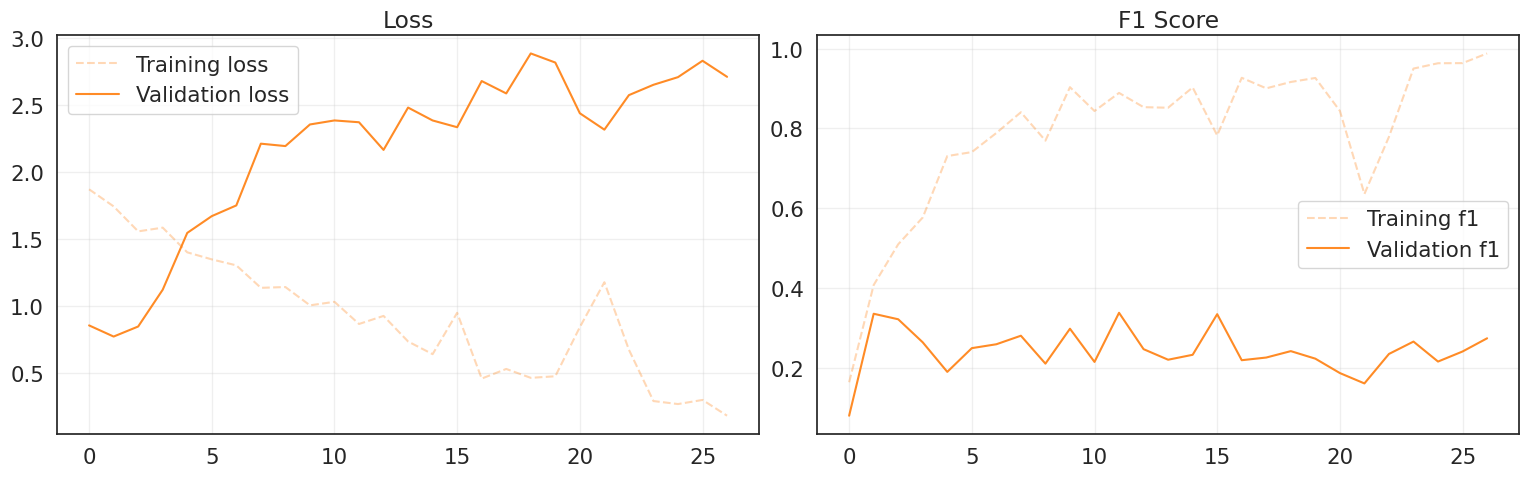

In [ ]:
# @title Plot Hitory
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

In [ ]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in val_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = cnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

# 6️⃣ Evaluation

## __Validation Performance__

In [ ]:
import cv2
import numpy as np
import os
import pandas as pd
from tqdm.notebook import tqdm

# --- CONFIG ---
TEST_DIR = './test_data/'                # Where your big test images are
TEMP_PATCH_DIR = './test_patches_temp/'   # Output folder

# --- SETTINGS (MUST MATCH TRAINING EXACTLY) ---
PATCH_SIZE = 224      # Native Resolution (No Resizing)
STRIDE = 224          # No Overlap for Testing (Faster, standard practice)
MASK_RATIO_THRESH = 0.01

# Setup Folders
img_dest = os.path.join(TEMP_PATCH_DIR, "images")
mask_dest = os.path.join(TEMP_PATCH_DIR, "masks")
os.makedirs(img_dest, exist_ok=True)
os.makedirs(mask_dest, exist_ok=True)

# Find Images
test_files = [f for f in os.listdir(TEST_DIR) if f.startswith('img') and f.endswith(('.png', '.jpg'))]
patch_data = []

print(f"🔪 Slicing {len(test_files)} Test Slides (High Fidelity 224x224)...")

for filename in tqdm(test_files):
    # 1. Match Paths
    img_path = os.path.join(TEST_DIR, filename)

    # Try generic mask replacement
    mask_name = filename.replace('img', 'mask').replace('.jpg', '.png')
    mask_path = os.path.join(TEST_DIR, mask_name)
    if not os.path.exists(mask_path):
        mask_name = filename.replace('img', 'mask') # Fallback
        mask_path = os.path.join(TEST_DIR, mask_name)

    if not os.path.exists(mask_path):
        print(f"⚠️ Mask missing for {filename}, skipping...")
        continue

    # 2. Load
    image = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if image is None or mask is None: continue

    # --- NORMALIZATION (Crucial) ---
    # Must use same normalization as training
    try:
        image = normalize_stain(image)
        image = araujo_contrast_stretching(image)
    except:
        pass # Skip if image is too white/empty

    # 3. Slice Loop
    h, w, _ = image.shape
    patch_id = 0

    for y in range(0, h - PATCH_SIZE + 1, STRIDE):
        for x in range(0, w - PATCH_SIZE + 1, STRIDE):

            # Extract (Native 224x224)
            img_patch = image[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            mask_patch = mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

            # Filter Tissue
            # We use the MASK to find tumor regions to test on
            tumor_pixels = np.count_nonzero(mask_patch)
            tumor_ratio = tumor_pixels / (PATCH_SIZE**2)

            if tumor_ratio >= MASK_RATIO_THRESH:

                # Save (No Resize)
                patch_name = f"{filename[:-4]}_p{patch_id}.png"

                cv2.imwrite(os.path.join(img_dest, patch_name), img_patch)
                cv2.imwrite(os.path.join(mask_dest, patch_name), mask_patch)

                # Record metadata
                patch_data.append({
                    'original_image': filename,
                    'filename': patch_name,
                    'label': 'Unknown' # Test data has no labels usually
                })
                patch_id += 1

# Save CSV
test_csv_path = os.path.join(TEMP_PATCH_DIR, "test_patches.csv")
test_df = pd.DataFrame(patch_data)
test_df.to_csv(test_csv_path, index=False)
print(f"✅ Generated {len(test_df)} test patches.")

🔪 Slicing 477 Test Slides (High Fidelity 224x224)...


  0%|          | 0/477 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import shutil
test_csv_path = os.path.join(TEMP_PATCH_DIR, "test_patches.csv")

# Create output directory for test features
test_features_dir = os.path.join(TEMP_PATCH_DIR, "features")

# --- FIX: Clear the features directory to ensure fresh extraction ---
if os.path.exists(test_features_dir):
    shutil.rmtree(test_features_dir)
os.makedirs(test_features_dir, exist_ok=True)

# Run Feature Extraction
extract_features_pipeline(
    csv_path=test_csv_path,             # The CSV we just made
    images_dir=img_dest,                # The folder with test patch images
    output_dir=test_features_dir,       # Where to save .pt files
    batch_size=64
)

🚀 Starting Extraction with Phikon on: cuda
⏳ Downloading/Loading Pathology Foundation Model (Phikon)...


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Extracting Features:   0%|          | 0/477 [00:00<?, ?it/s]

✅ Completed. Features saved in: ./test_patches_temp/features


# 7️⃣ Test Inference

## __Test Set Prediction with TTA__

In [ ]:
# --- CONFIG ---
MODEL_PATH = "best_mil_model_f1_c3.pth"
TEST_FEATS_DIR = os.path.join(TEMP_PATCH_DIR, "features")
USE_TTA = False  # ✅ ADVICE 16: Disable Test-Time Augmentation as it decreased F1
NUM_TTA_AUGS = 0 # No TTA augmentations if TTA is disabled

# 1. Load Test Data (In-Memory)
print("📥 Loading Test Data into RAM...")
test_files = glob.glob(os.path.join(TEST_FEATS_DIR, "*.pt"))
test_bags = []

for path in tqdm(test_files):
    data = torch.load(path, map_location=torch.device('cpu'))
    test_bags.append({
        'features': data['features'],
        'slide_id': data['slide_id']
    })

print(f"📊 Loaded {len(test_bags)} test slides.")

# 2. Load Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerMIL(num_classes=4, input_dim=768).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# 3. Initialize TTA (if enabled)
if USE_TTA:
    tta_wrapper = TTAWrapper(model, num_augmentations=NUM_TTA_AUGS)
    print(f"✅ TTA Enabled with {NUM_TTA_AUGS} augmentations")

# 4. Predict Loop
predictions = []
class_names = ['Luminal A', 'Luminal B', 'HER2(+)', 'Triple negative']

print("\n🚀 Running Inference...")

with torch.no_grad():
    for bag in tqdm(test_bags):
        features = bag['features'].to(device)
        slide_id = bag['slide_id']

        if USE_TTA:
            # ADVICE 16: Use TTA for robust predictions
            avg_logits, all_logits = tta_wrapper.predict(features)
            logits = avg_logits

            # Calculate prediction variance (uncertainty metric)
            all_probs = torch.softmax(all_logits, dim=2)  # [num_aug, 1, num_classes]
            variance = all_probs.var(dim=0).max().item()
        else:
            # Standard forward pass
            logits, *_, = model(features)
            variance = 0.0

        # Get Class Prediction
        pred_idx = torch.argmax(logits, dim=1).item()
        pred_label = class_names[pred_idx]

        # Get Confidence Score (Softmax)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        confidence = probs[pred_idx]

        predictions.append({
            'slide_id': slide_id,
            'predicted_label': pred_label,
            'confidence': f"{confidence:.4f}",
            'variance': f"{variance:.4f}",  # Uncertainty measure
            'probabilities': probs
        })

# 5. Save Results
results_df = pd.DataFrame(predictions)
save_path = "final_test_predictions.csv"
results_df.to_csv(save_path, index=False)

print(f"\n✅ Done! Predictions saved to {save_path}")
print(f"   TTA: {'Enabled' if USE_TTA else 'Disabled'}")
print(results_df.head())

📥 Loading Test Data into RAM...


  0%|          | 0/477 [00:00<?, ?it/s]

📊 Loaded 477 test slides.

🚀 Running Inference...


  0%|          | 0/477 [00:00<?, ?it/s]


✅ Done! Predictions saved to final_test_predictions.csv
   TTA: Disabled
       slide_id  predicted_label confidence variance  \
0  img_0000.png        Luminal B     0.3295   0.0000   
1  img_0001.png        Luminal B     0.3004   0.0000   
2  img_0002.png          HER2(+)     0.3000   0.0000   
3  img_0003.png  Triple negative     0.3764   0.0000   
4  img_0004.png        Luminal A     0.3131   0.0000   

                                     probabilities  
0  [0.3196428, 0.32952157, 0.27029976, 0.08053591]  
1   [0.29489487, 0.3003782, 0.2714829, 0.13324405]  
2  [0.2904869, 0.27053043, 0.29996416, 0.13901846]  
3   [0.22129701, 0.207357, 0.19493294, 0.37641308]  
4   [0.31314948, 0.2853198, 0.2372516, 0.16427906]  


In [ ]:
# --- SUBMISSION GENERATION ---
# Map class names back to integers (must match your training mapping)
label_to_int = {
    "Luminal A": 0,
    "Luminal B": 1,
    "HER2(+)": 2,
    "Triple negative": 3
}

# 1. Prepare the dataframe
submission_df = results_df.copy()

# 2. Extract sample_index from slide_id (e.g., "img_0012.png" -> 12)
# We remove 'img_' and the extension, then convert to integer
submission_df['sample_index'] = submission_df['slide_id']

# 3. Convert string labels back to integers
submission_df['label'] = submission_df['predicted_label']

# 4. Sort by index (usually required) and select only the needed columns
final_submission = submission_df[['sample_index', 'label']].sort_values('sample_index')

# 5. Save
save_name = "submission_c3.csv"
final_submission.to_csv(save_name, index=False)

print(f"✅ Submission file saved as '{save_name}'")
print(f"   Shape: {final_submission.shape}")
print(final_submission.head())

✅ Submission file saved as 'submission_c3.csv'
   Shape: (477, 2)
   sample_index            label
0  img_0000.png        Luminal B
1  img_0001.png        Luminal B
2  img_0002.png          HER2(+)
3  img_0003.png  Triple negative
4  img_0004.png        Luminal A


# 📊 Results Summary

### Training Performance
- **Best Validation F1 score**: 0.4812
- **Best K-Fold Validation F1 score**: 0.4329
- **Best Test F1 score**: 0.3963